In [1]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /Users/osman/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/osman/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
%pip install pandas gensim pyLDAvis nltk networkx numpy matplotlib
import pandas as pd
import gensim
import gensim.corpora as corpora
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt
import nltk
import networkx as nx
import numpy as np

Note: you may need to restart the kernel to use updated packages.


In [ ]:
df = pd.read_csv('moldova_new.csv')
df.columns

In [ ]:
topics['CustomName'].value_counts()

# Stance and Topics Analysis

In [ ]:
tweet = df[~df['is_retweet']]

## Topics

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

value_counts = tweet['CustomName'].value_counts().sort_values(ascending=False)


plt.figure(figsize=(12, 8))
plt.grid(axis='x')
plt.gca().set_axisbelow(True)
sns.barplot(x=value_counts.values, y=value_counts.index, palette="viridis")

plt.xscale('log')
plt.xlabel("Tweet Count")
plt.ylabel("Topic Name")
plt.title("Tweet Count per BERTopic Label")
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()


In [ ]:
relevant_topic_descriptions = {
    0: "Moldova, EU membership, Russia, and regional identity",
    1: "President Maia Sandu and Moldovan presidential elections",
    3: "Chisinau city infrastructure, traffic, and airport news",
    4: "Ukraine, Russia, NATO, and post-Soviet geopolitics",
    6: "Eastern European countries and regional cooperation",
    7: "Referendum vote results, diaspora turnout, and majority",
    10: "Moldova Independence Day and national celebrations",
    11: "Police activity, arrests, and car incidents",
    12: "Desire to join EU and ensure stability",
    13: "Orthodox Church, religious leaders, and Russian influence",
    16: "Ukrainian armed forces and Russia-Ukraine conflict",
    18: "Women, career, personal choices, and Moldovan media",
    19: "Traffic police, border control, and customs checks",
    20: "Justice ministry reforms and EU cooperation plans",
    21: "Traditional women’s roles and gender-based violence",
    22: "Israel, Lebanon, foreign citizens, and Jewish affairs",
    25: "Russian media figures and disinformation, including Solovyov",
    27: "LGBT rights, propaganda laws, and civil society",
    28: "Ilan Shor, oligarchy, and pro-Russian political scandals",
    29: "War, weapons, and historical references to soldiers",
    30: "Putin, Trump, and geopolitical propaganda discourse",
    31: "Real estate in Chisinau and housing conditions",
    32: "Christian faith, rural life, and blessings",
    33: "Putin’s admissions and statements on Russian politics",
    34: "Ballots, large-scale voting, and presidential election logistics",
    35: "Prime Minister visits and diplomatic relations",
}

In [ ]:
ids = [0, 1, 3, 4, 6, 7, 10, 11, 12, 13, 16, 18, 19, 20, 21, 22, 25, 27, 28, 29, 30, 31, 32, 33, 34, 35]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

value_counts = tweet.loc[tweet['topic'].isin(ids),'Topic'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
plt.grid(axis='x')
plt.gca().set_axisbelow(True)
sns.barplot(x=value_counts.values, y=value_counts.index, palette="viridis")

plt.xscale('log')
plt.xlabel("Tweet Count")
plt.ylabel("Topic Name")
plt.title("Tweet Count per BERTopic Label")
plt.tight_layout()

plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.ticklabel_format(style='plain', axis='x')
plt.show()

In [ ]:
tweet["language_group"] = tweet["language"].apply(
    lambda x: x if x in ["English", "Romanian", "Russian"] else "Other"
)

In [ ]:
tweet['language_group']

In [ ]:
filtered_tweet = tweet.loc[tweet['topic'].isin(ids)]

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Crosstab: rows = topics, columns = language
ct = pd.crosstab(filtered_tweet["CustomName"], filtered_tweet["language_group"])

# Optional: normalize per row to see proportions
# ct = ct.div(ct.sum(axis=1), axis=0)

ct.plot(kind="bar", stacked=True, figsize=(12, 8), colormap="tab20")

plt.title("Topic Distribution by Language")
plt.xlabel("Topic")
plt.yscale('log')
plt.ylabel("Tweet Count")
plt.legend(title="Language")
plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns

# Normalize by column (language)
ct_norm = pd.crosstab(filtered_tweet["CustomName"], filtered_tweet["language_group"], normalize='columns')

plt.figure(figsize=(12, 8))
sns.heatmap(ct_norm, annot=True, cmap="YlGnBu", fmt=".2f")

plt.title("Normalized Topic Proportion per Language")
plt.xlabel("Language")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()


## Stance

In [ ]:
import seaborn as sns

# Normalize by column (language)
ct_norm = pd.crosstab(filtered_tweet["stance"], filtered_tweet["language_group"], normalize='columns')

plt.figure(figsize=(12, 8))
sns.heatmap(ct_norm, annot=True, cmap="YlGnBu", fmt=".2f")

plt.title("Normalized Topic Proportion per Language")
plt.xlabel("Language")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()


## Sentiment

In [ ]:
import seaborn as sns

# Normalize by column (language)
ct_norm = pd.crosstab(filtered_tweet["sentiment"], filtered_tweet["language_group"], normalize='columns')

plt.figure(figsize=(12, 8))
sns.heatmap(ct_norm, annot=True, cmap="YlGnBu", fmt=".2f")

plt.title("Normalized Topic Proportion per Language")
plt.xlabel("Language")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

# Stance Extraction, Transformer

## Political agreement, original test

In [ ]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

tweet = "I can't believe they're still supporting that policy. It's ruining everything."
labels = ["pro", "against", "neutral"]
hypothesis_template = "This tweet is {} the subject."

result = classifier(tweet, labels, hypothesis_template=hypothesis_template)
print(result)

In [ ]:
from transformers import pipeline
import pandas as pd

classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=0) 

labels = ["pro", "against", "neutral"]
template = "This tweet expresses a {} opinion about the subject."

def classify_batch(texts):

    results = classifier(texts, labels, hypothesis_template=template)
    # Handle single vs. batched output format
    if isinstance(results, dict):  
        results = [results]
    return [r['labels'][0] for r in results]

batch_size = 32
stances = []
for i in range(0, len(df), batch_size):
    batch = df["translatedContentText"].iloc[i:i+batch_size].fillna("").tolist()
    stances.extend(classify_batch(batch))

df["stance"] = stances


In [ ]:
len(stances)

In [ ]:
df['stance'] = pd.Series(stances)

In [ ]:
df[df['stance'].isna()]

Sentiment

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import torch

# Load model and tokenizer
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)


In [ ]:
def compute_sentiment(tweet):
    
    inputs = tokenizer(tweet, return_tensors="pt", truncation=True, max_length=512)

    # Forward pass
    with torch.no_grad():
        logits = model(**inputs).logits

    # Convert to probabilities
    probs = softmax(logits.numpy()[0])
    labels = ['negative', 'neutral', 'positive']

    max_idx = np.argmax(probs)

    # Get the corresponding label and probability
    top_label = labels[max_idx]
    return top_label


df['sentiment'] = df['translatedContentText'].apply(compute_sentiment)
df['sentiment']

In [ ]:
# Plot sentiment score distributions
plt.figure(figsize=(20, 10))

part = df[df['mentions_stoianoglo']]

plt.subplot(2, 3, 5)
plt.hist(part['sentiment'], edgecolor='black')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Political agreement, improved

In [ ]:
from transformers import pipeline

# Predefined topics (index → description)
relevant_topic_descriptions = {
    0: "Moldova, EU membership, Russia, and regional identity",
    1: "President Maia Sandu and Moldovan presidential elections",
    3: "Chisinau city infrastructure, traffic, and airport news",
    4: "Ukraine, Russia, NATO, and post-Soviet geopolitics",
    6: "Eastern European countries and regional cooperation",
    7: "Referendum vote results, diaspora turnout, and majority",
    10: "Moldova Independence Day and national celebrations",
    11: "Police activity, arrests, and car incidents",
    12: "Desire to join EU and ensure stability",
    13: "Orthodox Church, religious leaders, and Russian influence",
    16: "Ukrainian armed forces and Russia-Ukraine conflict",
    18: "Women, career, personal choices, and Moldovan media",
    19: "Traffic police, border control, and customs checks",
    20: "Justice ministry reforms and EU cooperation plans",
    21: "Traditional women’s roles and gender-based violence",
    22: "Israel, Lebanon, foreign citizens, and Jewish affairs",
    25: "Russian media figures and disinformation, including Solovyov",
    27: "LGBT rights, propaganda laws, and civil society",
    28: "Ilan Shor, oligarchy, and pro-Russian political scandals",
    29: "War, weapons, and historical references to soldiers",
    30: "Putin, Trump, and geopolitical propaganda discourse",
    31: "Real estate in Chisinau and housing conditions",
    32: "Christian faith, rural life, and blessings",
    33: "Putin’s admissions and statements on Russian politics",
    34: "Ballots, large-scale voting, and presidential election logistics",
    35: "Prime Minister visits and diplomatic relations",
}

topic_list = list(relevant_topic_descriptions.values())
topic_to_index = {desc: idx for idx, desc in relevant_topic_descriptions.items()}

# Few-shot examples: tweets + correct stand stance labels
few_shots = [
    ("I fully support Maia Sandu's reform agenda.", ["pro-Sandu"]),
    ("Stoianoglo's policies are destroying trust.", ["anti-Stoianoglo"]),
    ("They mentioned both candidates without taking a side.", ["neutral-Stoianoglo", "neutral-Sandu"]),
]

def build_context(tweet: str) -> str:
    ctx = ""
    for text, labels in few_shots:
        ctx += f"Tweet: {text}\nLabels: {','.join(labels)}\n\n"
    ctx += f"Tweet: {tweet}\nLabels:"
    return ctx

hypotheses = {
    "pro-Stoianoglo":     "This tweet **supports** Alexander Stoianoglo.",
    "anti-Stoianoglo":    "This tweet **opposes** Alexander Stoianoglo.",
    "neutral-Stoianoglo": "This tweet **mentions** Stoianoglo without a stance.",
    "pro-Sandu":          "This tweet **supports** Maia Sandu.",
    "anti-Sandu":         "This tweet **opposes** Maia Sandu.",
    "neutral-Sandu":      "This tweet **mentions** Sandu without a stance.",
    "non-relevant to Stoianoglo": "This tweet is **not about** Stoianoglo.",
    "non-relevant to Sandu":      "This tweet is **not about** Sandu.",
}

stances = list(hypotheses.keys())

# Load NLI zero-shot model
zs = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

def predict(tweet: str) -> list:
    # 1. Topic classification -> index
    t_res = zs(tweet, topic_list, multi_label=False)
    top_topic = t_res["labels"][0]
    topic_idx = topic_to_index[top_topic]

    # # 2. Stance classification
    # stances = [
    #     "pro-Stoianoglo", "anti-Stoianoglo", "neutral-Stoianoglo",
    #     "pro-Sandu", "anti-Sandu", "neutral-Sandu", "non-relevant to Stoianoglo", "non-relevant to Sandu" 
    # ]
    # hyp = "This tweet is {} the two candidates."
    ctx = build_context(tweet)
    # print(ctx)
    # s_res = zs(ctx, stances, hypothesis_template=hyp, multi_label=True)

    # Get entailment scores per specific hypothesis
    s_scores = {label: zs(ctx, [label], hypothesis_template=hypotheses[label], multi_label=False)["scores"][0]
                for label in stances}

    # Map scores to Yes/No
    decisions = {label: "Yes" if s_scores[label] > 0.5 else "No" for label in stances}

    # 3. Map to Yes/No using threshold and fix non-relevant logic
    decisions = {lab: ("Yes" if score > 0.5 else "No")
                 for lab, score in zip(s_res["labels"], s_res["scores"])}
    # Stoianoglo non-relevance
    if any(decisions[s] == "Yes" for s in stances[:3]):
        decisions["non-relevant to Stoianoglo"] = "No"
    else:
        decisions["non-relevant to Stoianoglo"] = "Yes"

    # Sandu non-relevance
    if any(decisions[s] == "Yes" for s in stances[3:6]):
        decisions["non-relevant to Sandu"] = "No"
    else:
        decisions["non-relevant to Sandu"] = "Yes"

    # 4. Return [topic_index] + stance answers
    return [topic_idx] + [decisions[s] for s in stances]

# 🔎 Example
tweet = "Stoianoglo is failing the judiciary reforms."
print(predict(tweet))
# ➞ [20, 'No', 'Yes', 'No', 'No', 'No', 'No', 'No']


In [ ]:
from transformers import pipeline

# === 1. Topic setup ===
relevant_topic_descriptions = {
    0: "Moldova, EU membership, Russia, and regional identity",
    1: "President Maia Sandu and Moldovan presidential elections",
    3: "Chisinau city infrastructure, traffic, and airport news",
    4: "Ukraine, Russia, NATO, and post-Soviet geopolitics",
    6: "Eastern European countries and regional cooperation",
    7: "Referendum vote results, diaspora turnout, and majority",
    10: "Moldova Independence Day and national celebrations",
    11: "Police activity, arrests, and car incidents",
    12: "Desire to join EU and ensure stability",
    13: "Orthodox Church, religious leaders, and Russian influence",
    16: "Ukrainian armed forces and Russia‑Ukraine conflict",
    18: "Women, career, personal choices, and Moldovan media",
    19: "Traffic police, border control, and customs checks",
    20: "Justice ministry reforms and EU cooperation plans",
    21: "Traditional women’s roles and gender‑based violence",
    22: "Israel, Lebanon, foreign citizens, and Jewish affairs",
    25: "Russian media figures and disinformation, including Solovyov",
    27: "LGBT rights, propaganda laws, and civil society",
    28: "Ilan Shor, oligarchy, and pro‑Russian political scandals",
    29: "War, weapons, and historical references to soldiers",
    30: "Putin, Trump, and geopolitical propaganda discourse",
    31: "Real estate in Chisinau and housing conditions",
    32: "Christian faith, rural life, and blessings",
    33: "Putin’s admissions and statements on Russian politics",
    34: "Ballots, large‑scale voting, and presidential election logistics",
    35: "Prime Minister visits and diplomatic relations",
}

topic_list = list(relevant_topic_descriptions.values())
topic_to_index = {desc: idx for idx, desc in relevant_topic_descriptions.items()}

few_shots = [
    # --- Pro / Anti Stoianoglo ---
    ("I think Alexander Stoianoglo has done a great job as prosecutor.", ["pro-Stoianoglo"]),
    ("Stoianoglo is clearly corrupt and needs to be removed.", ["anti-Stoianoglo"]),
    
    # --- Pro / Anti Sandu ---
    ("Maia Sandu is the best thing that’s happened to Moldova in years.", ["pro-Sandu"]),
    ("I can't trust Sandu anymore, her presidency has failed us.", ["anti-Sandu"]),

    # --- Neutral mentions ---
    ("Stoianoglo met with EU officials today.", ["neutral-Stoianoglo"]),
    ("Maia Sandu gave a press conference in Chișinău.", ["neutral-Sandu"]),

    # --- Irrelevant / non-relevant ---
    ("The streets in Chișinău are full of potholes again.", ["non-relevant to Stoianoglo", "non-relevant to Sandu"]),
    ("Moldova is celebrating Independence Day with concerts and parades.", ["non-relevant to Stoianoglo", "non-relevant to Sandu"]),

    # --- Multi-label case ---
    ("Both Sandu and Stoianoglo have made mistakes, but Sandu is trying harder.", ["neutral-Stoianoglo", "pro-Sandu"]),

    # --- Subtle support/criticism ---
    ("Sandu's economic reforms are ambitious, but time will tell if they work.", ["neutral-Sandu"]),
    ("I don't agree with how Stoianoglo handled the last case.", ["anti-Stoianoglo"]),
]

def build_context(tweet: str) -> str:
    ctx = ""
    for text, labels in few_shots:
        ctx += f"Tweet: {text}\nLabels: {','.join(labels)}\n\n"
    return ctx + f"Tweet: {tweet}\nLabels:"

# Load model
zs = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Hypotheses for each stance
hypotheses = {
    "pro-Stoianoglo":     "This sentence {} express support for Alexander Stoianoglo.",
    "anti-Stoianoglo":    "This sentence {} express opposition to Alexander Stoianoglo.",
    "neutral-Stoianoglo": "This sentence {} express a neutral stance for Alexander Stoianoglo.",
    "pro-Sandu":          "This sentence {} express support for Maia Sandu.",
    "anti-Sandu":         "This sentence {} express opposition to Maia Sandu.",
    "neutral-Sandu":      "This sentence {} express a neutral stance for Maia Sandu.",
    "non-relevant to Stoianoglo": "This sentence {} mention Alexander Stoianoglo",
    "non-relevant to Sandu":  "This sentence {} mention Maia Sandu",
}

stance_labels = ["does", "does not"]

def predict(tweet: str) -> list:
    # Topic classification
    hyp = "This sentence is about the following topic: {}"
    t_res = zs(tweet, topic_list, hypothesis_template=hyp, multi_label=False)
    topic_idx = topic_to_index[t_res["labels"][0]]

    # Build few-shot context
    ctx = build_context(tweet)

    # For each stance hypothesis, ask if it "does" or "does not" apply
    decisions = {}
    for stance, hypothesis in hypotheses.items():
        res = zs(tweet, stance_labels, hypothesis_template=hypothesis, multi_label=False)
        top_label = res["labels"][0]
        if stance.startswith("non-relevant"):
            decisions[stance] = "Yes" if top_label == "does not" else "No"
        else:
            decisions[stance] = "Yes" if top_label == "does" else "No"

    return [topic_idx] + [decisions[h] for h in hypotheses]

# Example use
tweet = "I support Maia Sandu and think Stoianoglo has failed."
print(predict(tweet))
# ➝ [1, 'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'No', 'No']


In [ ]:
df = pd.read_csv('moldova_updated.csv')
df['translatedContentText']

# Emotion Analysis

In [ ]:
df.to_csv('moldova1.csv', index=False)

In [ ]:
# Example usage:
positive_columns = ['Admiration', 'Approval', 'Joy', 'Love', 'Optimism']
negative_columns = ['Anger', 'Disgust', 'Fear', 'Pessimism', 'Sadness']

# Function to compute sentiment per tweet
def compute_tweet_sentiment(row, pos_cols, neg_cols, epsilon=1e-6):
    pos_values = row[pos_cols].fillna(0).values
    neg_values = row[neg_cols].fillna(0).values

    pos_sorted = sorted(pos_values, reverse=True)
    neg_sorted = sorted(neg_values, reverse=True)
    weights = np.linspace(1, 0.1, len(pos_sorted))

    pos_weighted = np.average(pos_sorted, weights=weights)
    neg_weighted = np.average(neg_sorted, weights=weights)
    sentiment_score = (pos_weighted - neg_weighted) / (pos_weighted + neg_weighted + epsilon)

    return sentiment_score

# Apply to dataframe
df['sentiment_score'] = df.apply(lambda row: compute_tweet_sentiment(row, positive_columns, negative_columns), axis=1)


In [ ]:
# Plot sentiment score distributions
plt.figure(figsize=(20, 10))

part = df

plt.subplot(2, 3, 5)
plt.hist(part['sentiment_score'], bins=30, color='purple', edgecolor='black')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
from rapidfuzz import fuzz

def mentions_candidate_any_part(text, name_parts, threshold=80):
    text = text.lower()
    return any(fuzz.partial_ratio(text, part.lower()) > threshold for part in name_parts)

# Example usage
# Define aliases for Maia Sandu
sandu_aliases = [
    "Maia Sandu",
    "Maia",
    "Sandu",
    "Președinta Maia Sandu",
    "Doamna Maia Sandu",
    "Președinta Republicii Moldova",
    "Șefa statului",
    "Майя Санду",
    "Президент Санду"
]
df['mentions_sandu'] = df['cleanText'].apply(lambda x: mentions_candidate_any_part(str(x), sandu_aliases))
df['mentions_sandu'].value_counts()

In [ ]:
stoianoglo_aliases = [
    "Alexandr Stoianoglo",
    "Alexandru Stoianoglo",
    "Aleksandr",
    "Stoyanoglu",
    "Aleksandr Stoyanoglu"
    "Stoianoglo",
    "Alexandr",
    "Александр Стояногло",
    "Стояногло",
    "Александр",
    "Procurorul general",
    "Fostul procuror general",
    "Șeful procuraturii",
    "Procuror Stoianoglo"
]

In [ ]:
def mentions_stoianoglo(text, aliases=stoianoglo_aliases, threshold=80):
    text = text.lower()
    return any(fuzz.partial_ratio(text, alias.lower()) > threshold for alias in aliases)

# Apply to your DataFrame
df['mentions_stoianoglo'] = df['cleanText'].apply(lambda x: mentions_stoianoglo(str(x)))
df['mentions_stoianoglo'].value_counts()


In [ ]:
# Create candidate-specific full mention-based tweet networks (not just negative)
G_sandu_all = nx.DiGraph()
G_stoianoglo_all = nx.DiGraph()

# Function to build a candidate-specific tweet network
def build_tweet_network(G, filter_column):
    filtered_df = df[df[filter_column]]
    for _, row in filtered_df.iterrows():
        user = row['twitterData.twitterUserId']
        tweet_id = row['twitterData.tweetId']
        G.add_node(tweet_id, sentiment_score=row['sentiment_score'])

        if pd.notna(row['twitterData.engagementType']) and pd.notna(row['twitterData.engagementParentId']):
            parent_id = row['twitterData.engagementParentId']
            if parent_id in df['twitterData.tweetId'].values:
                G.add_edge(tweet_id, parent_id, interaction=row['twitterData.engagementType'])

# Build the networks
build_tweet_network(G_sandu_all, 'mentions_sandu')
build_tweet_network(G_stoianoglo_all, 'mentions_stoianoglo')

# Save to GEXF
nx.write_gexf(G_sandu_all, "sandu_full_tweet_network.gexf")
nx.write_gexf(G_stoianoglo_all, "stoianoglo_full_tweet_network.gexf")

In [ ]:
# Define a sentiment threshold below which a tweet is considered negative
NEGATIVE_THRESHOLD = 0

# Filter negative tweets that mention Maia Sandu or Alexandr Stoianoglo
df['is_negative'] = df['sentiment_score'] < NEGATIVE_THRESHOLD
df['target_sandu'] = df['mentions_sandu'] & df['is_negative']
df['target_stoianoglo'] = df['mentions_stoianoglo'] & df['is_negative']

# Build negative sentiment networks for each candidate
G_sandu = nx.DiGraph()
G_stoianoglo = nx.DiGraph()

# Helper function to add nodes and edges to the appropriate graph
def add_to_graph(G, row):
    user = row['twitterData.twitterUserId']
    tweet_id = row['twitterData.tweetId']
    G.add_node(user, tweet_id=tweet_id, sentiment=row['sentiment_score'])

    # If the tweet is an engagement, add an edge
    if pd.notna(row['twitterData.engagementType']) and pd.notna(row['twitterData.engagementParentId']):
        parent_row = df[df['twitterData.tweetId'] == row['twitterData.engagementParentId']]
        if not parent_row.empty:
            parent_user = parent_row.iloc[0]['twitterData.twitterUserId']
            G.add_edge(user, parent_user, type=row['twitterData.engagementType'], weight=abs(row['sentiment_score']))

# Build each graph from the filtered DataFrame
for _, row in df[df['target_sandu']].iterrows():
    add_to_graph(G_sandu, row)

for _, row in df[df['target_stoianoglo']].iterrows():
    add_to_graph(G_stoianoglo, row)

# Network Preprocessing

In [ ]:
# Drop rows where either tweet ID or parent ID is missing
df_valid = df.dropna(subset=['twitterData.tweetId', 'twitterData.engagementParentId'])

# Set of all tweet IDs that exist in the dataset
existing_tweet_ids = set(df['twitterData.tweetId'].dropna())

# Set of all parent tweet IDs that are referenced
referenced_parent_ids = set(df_valid['twitterData.engagementParentId'])

# Find parent IDs not present in the dataset
missing_parents = referenced_parent_ids - existing_tweet_ids

# Count of missing parent tweets
missing_parent_count = len(missing_parents)

print(f"Number of missing parent tweets: {missing_parent_count}")


In [ ]:
import pandas as pd
import re
from collections import Counter, defaultdict

# Ensure 'timePublished' is in datetime format if needed
if not pd.api.types.is_datetime64_any_dtype(df['timePublished']):
    df['timePublished'] = pd.to_datetime(df['timePublished'], unit='ms', errors='coerce')

# Step 1: Filter valid child tweets (with both tweetId and engagementParentId)
df_valid = df.dropna(subset=['twitterData.tweetId', 'twitterData.engagementParentId'])

# Step 2: Identify parent tweet IDs that are missing from dataset
existing_ids = set(df['twitterData.tweetId'].dropna())
referenced_ids = set(df_valid['twitterData.engagementParentId'])
missing_parents = referenced_ids - existing_ids

# Step 3: Get all rows referencing missing parent tweets
orphans = df_valid[df_valid['twitterData.engagementParentId'].isin(missing_parents)]

# Step 4: Build placeholder rows
placeholder_rows = []
grouped = orphans.groupby('twitterData.engagementParentId')

for pid, group in grouped:
    # Most common language and topic
    lang = Counter(group['language'].dropna()).most_common(1)
    topic = Counter(group['Topic'].dropna()).most_common(1)
    t = Counter(group['topic'].dropna()).most_common(1)

    # Try to extract content from retweets
    retweets = group[group['twitterData.engagementType'] == 'retweet']
    original_texts = []
    author_candidates = []

    for text in retweets['ContentText'].dropna():
        match = re.match(r'^RT\s+@(\w+):\s*(.*)', text)
        if match:
            print('aaa')
            author_candidates.append(match.group(1))  # screenname
            cleaned = match.group(2).strip()
            if cleaned:
                original_texts.append(cleaned)

    # Determine most common cleaned text and author
    content_text = Counter(original_texts).most_common(1)
    clean_text = content_text[0][0] if content_text else None

    original_author = Counter(author_candidates).most_common(1)
    author_name = original_author[0][0] if original_author else None

    group_times = group['timePublished'].dropna()
    oldest_time = group_times.min() if not group_times.empty else pd.NaT

    placeholder = {
        'twitterData.tweetId': pid,
        'language': lang[0][0] if lang else None,
        'Topic': topic[0][0] if topic else None,
        'topic': t[0][0] if t else None,
        'ContentText': clean_text,
        'cleanText': clean_text,
        'translatedContentText': clean_text,
        'author': f"@{author_name}" if author_name else None,
        'twitterData.twitterAuthorScreenname': author_name,
        'timePublished': oldest_time,
        'name': None,
        'twitterData.twitterUserId': None,
        'twitterData.engagementType': 'tweet',  # inferred as original
    }

    placeholder_rows.append(placeholder)

# Step 5: Create DataFrame and align columns
placeholder_df = pd.DataFrame(placeholder_rows)
placeholder_df = placeholder_df.reindex(columns=df.columns)  # ensure same structure


In [ ]:
df = pd.concat([df, placeholder_df])
df

In [ ]:
# Drop rows without tweet IDs (just in case)
df = df.dropna(subset=['twitterData.tweetId'])

import numpy as np

def safe_int(value):
    try:
        if pd.isna(value):
            return 0
        return int(float(value))  # in case it's a string like "123.0"
    except (ValueError, TypeError):
        return 0


# Initialize a directed graph
G = nx.DiGraph()

# Map engagement types to node shapes
shape_map = {
    'retweet': 's',
    'reply': 'o',
    'quote': 'D',
    'tweet': '^',
    pd.NA: 'x',
    None: 'x',
    float('nan'): 'x'
}

# Map languages to colors
language_colors = {}  # auto-map colors
available_colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'gray', 'brown']
lang_idx = 0

# Add nodes with attributes
for _, row in df.iterrows():
    tid = row['twitterData.tweetId']
    lang = row.get('language', 'unknown')
    etype = row.get('twitterData.engagementType', 'tweet')  # assume original if missing
    topic = row.get('Topic')

    likes = safe_int(row.get('twitterData.likeCount', 0))
    if likes == 0:
        likes = 1  # fallback to 1

    if lang not in language_colors:
        language_colors[lang] = available_colors[lang_idx % len(available_colors)]
        lang_idx += 1

    G.add_node(tid,
               engagementType=etype,
               language=lang,
               shape=shape_map.get(etype, 'x'),
               topic=topic,
            #    color=language_colors[lang],
               like=likes)

# Add edges for retweets and replies/quotes (exclude original tweets)
for _, row in df.iterrows():
    source = row['twitterData.tweetId']
    target = row['twitterData.engagementParentId']
    etype = row.get('twitterData.engagementType')

    if pd.notna(target) and etype in ['retweet', 'reply', 'quote']:
        G.add_edge(source, target, edge_type=etype)

topic_groups = defaultdict(list)
for node, data in G.nodes(data=True):
    topic = data.get('topic') or data.get('Topic')
    if pd.notna(topic):
        topic_groups[topic].append(node)

# Add hub nodes and connect all topic-matching tweets to the hub
for topic, nodes in topic_groups.items():
    hub_id = f"hub_{topic}"

    # Add a special hub node
    G.add_node(hub_id,
               topic=topic,
               engagementType='hub',
               shape='x',
               language='hub',
               like=0,
               hub=True)

    # Add one edge per tweet in the topic to the hub
    for node in nodes:
        G.add_edge(node, hub_id, edge_type='topic_hub', weight=10)

print(f"Tweet interaction graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

In [ ]:
nx.write_gexf(G, "tweet_interaction_network_topics.gexf")

In [ ]:
import pandas as pd
import networkx as nx
from collections import defaultdict, Counter

# Drop missing tweet/user info
df = df.dropna(subset=['twitterData.tweetId', 'twitterData.twitterAuthorScreenname'])

# Map tweet ID → user
tweet_to_user = dict(zip(df['twitterData.tweetId'], df['twitterData.twitterAuthorScreenname']))

# Initialize directed graph
UG = nx.DiGraph()

# Track user-level metadata
user_topics = defaultdict(list)
user_languages = defaultdict(list)
user_followers = defaultdict(list)

# Track edges per interaction type
interaction_edges = defaultdict(int)

# Populate user metadata and edge weights
for _, row in df.iterrows():
    tid = row['twitterData.tweetId']
    uid = row['twitterData.twitterAuthorScreenname']
    etype = row.get('twitterData.engagementType')
    parent_tid = row.get('twitterData.engagementParentId')
    
    topic = row.get('Topic')
    lang = row.get('language')
    followers = row.get('twitterData.followerCount')

    if pd.notna(topic):
        user_topics[uid].append(topic)
    if pd.notna(lang):
        user_languages[uid].append(lang)
    if pd.notna(followers):
        try:
            user_followers[uid].append(int(float(followers)))
        except:
            pass

    if pd.notna(parent_tid) and etype in ['retweet', 'reply', 'quote']:
        target_uid = tweet_to_user.get(parent_tid)
        if target_uid and target_uid != uid:
            interaction_edges[(uid, target_uid, etype)] += 1

# Add user nodes with attributes
all_users = set(u for u, _, _ in interaction_edges.keys()) | set(v for _, v, _ in interaction_edges.keys())

for uid in all_users:
    most_common_topic = Counter(user_topics[uid]).most_common(1)
    most_common_language = Counter(user_languages[uid]).most_common(1)
    avg_followers = sum(user_followers[uid]) / len(user_followers[uid]) if user_followers[uid] else None

    UG.add_node(uid,
                most_common_topic=most_common_topic[0][0] if most_common_topic else None,
                most_common_language=most_common_language[0][0] if most_common_language else None,
                average_follower_count=avg_followers)

# Add interaction-type edges with weights
for (src, tgt, itype), count in interaction_edges.items():
    UG.add_edge(src, tgt, interaction_type=itype, weight=count)

print(f"User interaction graph has {UG.number_of_nodes()} nodes and {UG.number_of_edges()} edges.")


In [ ]:
nx.write_gexf(UG, "user_interaction_network.gexf")

# Translation

In [ ]:
from deep_translator import GoogleTranslator

def split_on_full_stops(text, max_len=5000):
    """ Split text into sentences based on full stops and ensure each chunk is within the limit. """
    sentences = text.split('.')
    chunks = []
    current_chunk = ""

    for sentence in sentences:
        sentence = sentence.strip()
        if not sentence:
            continue

        # Check if adding this sentence exceeds the max length
        if len(current_chunk) + len(sentence) + 1 < max_len:
            current_chunk += sentence + ". "
        else:
            # Save current chunk and start a new one
            chunks.append(current_chunk.strip())
            current_chunk = sentence + ". "

    # Add any remaining chunk
    if current_chunk:
        chunks.append(current_chunk.strip())

    return chunks

def translate_text_in_chunks(text, source_lang='auto', target_lang='en'):
    """ Translate text split into smaller sentences, handling errors gracefully. """
    translated_chunks = []

    # Split text into smaller sentences
    chunks = split_on_full_stops(text)

    for chunk in chunks:
        try:
            # Translate each chunk
            translated_chunk = GoogleTranslator(source=source_lang, target=target_lang).translate(chunk)
            translated_chunks.append(translated_chunk)
        except Exception as e:
            print(f"Skipping chunk due to error: {e}")
            translated_chunks.append(chunk)  # Keep original chunk if translation fails

    # Reassemble the translated text
    return " ".join(translated_chunks)

for key, value in failed.items():
    failed[key] = translate_text_in_chunks(value)

In [ ]:
from deep_translator import GoogleTranslator
from tqdm import tqdm

translated = {}

failed = {}

i = 0

for text in tqdm(data['ContentText']):
    try:
        translation = GoogleTranslator(source='auto', target='en').translate(text)
        translated[i] = translation
    except:
        print('whoopsies')
        failed[i] = text
    i+=1

In [ ]:
data.drop(columns='translatedContentText', inplace=True)

In [ ]:
f = pd.DataFrame.from_dict(failed, orient='index')
f

In [ ]:
for key, value in failed.items():
    test.loc[key, 'translatedContentText'] = value

In [ ]:
test.rename(columns={0: 'translatedContentText'}, inplace=True)

In [ ]:
test.to_csv('moldova.csv', index=False)

# Data Preprocessing

In [ ]:
df = df[~df['translatedContentText'].str.contains(r'\bRT\s@', na=False, case=False)]

In [ ]:
df['translatedContentText']

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def preprocess_tweet_lemmatized(text):
    if pd.isnull(text):
        return ''

    # Step 1: Meta-info removal
    text = re.sub(r'RT\s+', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   # URLs
    text = re.sub(r'@\w+', '', text)                    # Mentions
    text = re.sub(r'#\w+', '', text)                    # Hashtags
    text = re.sub(r'[^\w\s]', '', text)                 # Emojis & punctuation

    # Step 2: Tokenization
    tokens = word_tokenize(text)

    # Step 3: Normalization to [a-z]
    tokens = [re.sub(r'[^a-zA-Z]', '', token).lower() for token in tokens]

    # Step 4: Stopword filtering
    tokens = [token for token in tokens if token not in stop_words and token != '']

    # Step 5: Lemmatization
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return ' '.join(tokens)


In [ ]:
df['cleanText'] = df['translatedContentText'].apply(preprocess_tweet_lemmatized)

# NMF

In [ ]:
df = df.drop_duplicates(subset='cleanText')

# Remove super short entries
df = df[df['cleanText'].str.split().str.len() > 3]
df['cleanText'] = df['cleanText'].str.replace(r'#', '', regex=True)
df['cleanText'] = df['cleanText'].str.strip().replace(r'\s+', ' ', regex=True)

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Load your data
texts = df['cleanText'].dropna().tolist()

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
tfidf = tfidf_vectorizer.fit_transform(texts)

In [ ]:
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt

errors = []
topic_range = range(5, 100, 5)
for n_topics in topic_range:
    nmf = NMF(n_components=n_topics, random_state=42)
    nmf.fit(tfidf)
    errors.append(nmf.reconstruction_err_)

plt.plot(topic_range, errors, marker='o')
plt.title("NMF Reconstruction Error vs Number of Topics")
plt.xlabel("Num Topics")
plt.ylabel("Reconstruction Error")
plt.show()

In [ ]:
n_topics = 20  # Pick based on the elbow method
nmf_model = NMF(n_components=n_topics, random_state=42)
W = nmf_model.fit_transform(tfidf)
H = nmf_model.components_

# Top words per topic
feature_names = tfidf_vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(H):
    print(f"Topic {topic_idx + 1}: ", " | ".join([feature_names[i] for i in topic.argsort()[:-11:-1]]))

In [ ]:
from sklearn.metrics.pairwise import cosine_distances
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

dist_matrix = cosine_distances(H)
linkage_matrix = linkage(squareform(dist_matrix), method='average')

plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, labels=[f"{i}" for i in range(n_topics)])
plt.tight_layout()
plt.title("NMF Topic Hierarchy")
plt.show()

# BERTopic

In [ ]:
df.drop(columns=['topic', 'Topic'], inplace=True)
df.columns

In [ ]:
# Step 1–2: Remove duplicates and retweets
import re

df = df.drop_duplicates(subset='translatedContentText')
# df = df[~df['translatedContentText'].str.contains(r'\brt\s', case=False, na=False)]
df = df[~df['is_retweet']]

# Step 3: Define light cleaning for embeddings
def clean_for_bertopic(text):
    if pd.isnull(text):
        return ''
    
    text = re.sub(r'@\w+', '', text)                      # Remove mentions
    text = re.sub(r'#\w+', '', text)                         # Remove hashtag symbol, keep word
    text = re.sub(r'http\S+|www.\S+', '', text)           # Remove URLs
    text = re.sub(r'[^\x00-\x7F]+', '', text)             # Remove non-ASCII (emojis, signs)
    text = re.sub(r'\s+', ' ', text).strip()              # Normalize whitespace
    return text

# Step 4: Apply to create new column
df['bertopicText'] = df['translatedContentText'].apply(clean_for_bertopic)
df.dropna(subset=['bertopicText'], inplace=True)
df

In [ ]:
docs = df['bertopicText'].dropna().tolist()

In [ ]:
len(docs)

In [ ]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from bertopic.representation import MaximalMarginalRelevance

representation_model = MaximalMarginalRelevance(diversity=0.2)

# Optional: custom vectorizer to filter out rare terms
vectorizer_model = CountVectorizer(stop_words="english", min_df=5, ngram_range=(1, 3))

In [ ]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(docs, show_progress_bar=True)

In [ ]:
from umap import UMAP

umap_model=UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=41)

In [ ]:
topic_model = BERTopic(vectorizer_model=vectorizer_model,
                       n_gram_range=(1,3), min_topic_size=15, embedding_model=embedding_model,
                       umap_model=umap_model, nr_topics=40)
topics, probs = topic_model.fit_transform(docs)

In [ ]:
freq = topic_model.get_topic_info()
freq

In [ ]:
fig = topic_model.visualize_topics(); fig

In [ ]:
hierarchical_topics = topic_model.hierarchical_topics(docs)
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract the distance column
distances = hierarchical_topics['Distance'].sort_values().values

# Plot distances to observe elbow
plt.figure(figsize=(10, 5))
plt.plot(np.arange(len(distances)), distances)
plt.title("Hierarchical Merge Distances")
plt.xlabel("Merge Step")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

In [ ]:
new_topics = topic_model.reduce_outliers(docs, topics)

# # Reduce all outliers that are left with the "distributions" strategy
new_topics = topic_model.reduce_outliers(docs, topics, strategy="distributions")

In [ ]:
max(new_topics)

In [ ]:
topic_model.update_topics(docs, topics=new_topics, vectorizer_model=vectorizer_model)

In [ ]:
freq = topic_model.get_topic_info()
freq

In [ ]:
topic_labels = topic_model.generate_topic_labels(nr_words=10,
                                                 topic_prefix=False,
                                                 word_length=15,
                                                 separator=", ")
topic_labels

In [ ]:
topic_descriptions = {
    -1: "Miscellaneous or noisy tweets with unclear theme",
    0: "Moldova, EU membership, Russia, and regional identity",
    1: "President Maia Sandu and Moldovan presidential elections",
    2: "International sports results and competition rankings",
    3: "Chisinau city infrastructure, traffic, and airport news",
    4: "Ukraine, Russia, NATO, and post-Soviet geopolitics",
    5: "Bessarabian and Moldavian cultural symbols and heritage",
    6: "Eastern European countries and regional cooperation",
    7: "Referendum vote results, diaspora turnout, and majority",
    8: "Casual reactions, humor, and informal commentary",
    9: "Friends, events, and impressive or viral content",
    10: "Moldova Independence Day and national celebrations",
    11: "Police activity, arrests, and car incidents",
    12: "Desire to join EU and ensure stability",
    13: "Orthodox Church, religious leaders, and Russian influence",
    14: "Wine, agriculture, and Moldovan food industry",
    15: "Weather alerts: rain, floods, and heat warnings",
    16: "Ukrainian armed forces and Russia-Ukraine conflict",
    17: "Eurovision and music contest years and editions",
    18: "Women, career, personal choices, and Moldovan media",
    19: "Traffic police, border control, and customs checks",
    20: "Justice ministry reforms and EU cooperation plans",
    21: "Traditional women’s roles and gender-based violence",
    22: "Israel, Lebanon, foreign citizens, and Jewish affairs",
    23: "Automated bot actions and subreddit moderation",
    24: "COVID-19 cases, health data, and weekly reports",
    25: "Russian media figures and disinformation, including Solovyov",
    26: "Earthquake events and live broadcast reactions",
    27: "LGBT rights, propaganda laws, and civil society",
    28: "Ilan Shor, oligarchy, and pro-Russian political scandals",
    29: "War, weapons, and historical references to soldiers",
    30: "Putin, Trump, and geopolitical propaganda discourse",
    31: "Real estate in Chisinau and housing conditions",
    32: "Christian faith, rural life, and blessings",
    33: "Putin’s admissions and statements on Russian politics",
    34: "Ballots, large-scale voting, and presidential election logistics",
    35: "Prime Minister visits and diplomatic relations",
    36: "Random informal statements and everyday thoughts",
    37: "Numeric data or possibly spam image metadata",
    38: "Tech services, installations, and infrastructure updates"
}


In [ ]:
df['id'].nunique()

In [ ]:
df.columns

In [ ]:
freq = topic_model.get_topic_info()
df = df.merge(freq[['Topic', 'CustomName', 'Representation']], left_on='topic', right_on='Topic')

In [ ]:
df.to_csv('moldova_topics.csv', index=False)

In [ ]:
topic_model.set_topic_labels(topic_descriptions)

In [ ]:
len(topic_model.topics_)

In [ ]:
df['topic'] = topic_model.topics_

In [ ]:
merge = df[['id','bertopicText', 'topic', 'Topic', 'CustomName', 'Representation']]

In [ ]:
df.columns

In [ ]:
df.drop(columns=['topic',
       'bertopicText', 'CustomName', 'Representation'], inplace=True)

In [ ]:
df = df.merge(merge, on='id', how='left')

In [ ]:
df.to_csv('moldova_new.csv', index=False)

In [ ]:
from datetime import datetime
df['UTC time'] = df['timePublished'].apply(lambda ts: datetime.utcfromtimestamp(ts / 1000))

In [ ]:
df['UTC time'].max()

In [ ]:
topics_over_time = topic_model.topics_over_time(docs, df['UTC time'].to_list(), nr_bins=50)

In [ ]:
topic_model.visualize_topics_over_time(topics_over_time, custom_labels=True, topics=[0, 1, 6, 11, 9, 36, 35, 31])

In [ ]:
hierarchical_topics = topic_model.hierarchical_topics(docs)
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

In [ ]:
topic_model.visualize_heatmap()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

def suggest_topic_reduction(topic_model, threshold=0.75, plot_dendrogram=True):
    # Step 1: Extract topic embeddings (excluding outliers, -1)
    topic_embeddings = topic_model.topic_embeddings_
    topic_labels = list(topic_model.get_topic_info()['Topic'])
    valid_indices = [i for i, t in enumerate(topic_labels) if t != -1]
    topic_embeddings = topic_embeddings[valid_indices]

    # Step 2: Compute cosine similarity and convert to distance
    similarity = cosine_similarity(topic_embeddings)
    distance = 1 - similarity

    condensed = squareform(distance, checks=False)  # ✅ now it's 1D
    Z = linkage(condensed, method='average')
    # Step 3: Hierarchical clustering
    if plot_dendrogram:
        plt.figure(figsize=(12, 4))
        dendrogram(Z, labels=[str(t) for t in np.array(topic_labels)[valid_indices]], leaf_rotation=90)
        plt.title("Dendrogram of Topic Embeddings")
        plt.tight_layout()
        plt.show()

    clustering = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=1 - threshold,
    linkage='average',
    )
    clusters = clustering.fit_predict(distance)

    n_clusters = len(set(clusters))
    print(f"📉 Suggested number of topics: {n_clusters} based on threshold = {threshold}")
    return n_clusters


In [ ]:
suggested_n = suggest_topic_reduction(topic_model, threshold=0.75)
# topic_model_reduced = topic_model.reduce_topics(df['cleanText'].dropna().tolist(), nr_topics=suggested_n)
# topic_model_reduced.visualize_topics()

In [ ]:
topic_model_reduced = topic_model.reduce_topics(df['cleanText'].dropna().tolist(), nr_topics=15)
topic_model_reduced.visualize_topics()

In [ ]:
freq = topic_model_reduced.get_topic_info()
freq.head(10)

In [ ]:
topic_model_reduced.get_topic(0)

# LDA

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')

df['processed_text'] = df['cleanText']
# # Text preprocessing
def preprocess(text):
    # stop_words = set(stopwords.words('english'))
    # tokens = word_tokenize(text.lower())
    n_text = text.replace('#', '')
    tokens = n_text.split()
    return tokens

df['processed_text'] = df['cleanText'].astype(str).apply(preprocess)

# Create Dictionary and Corpus
dictionary = corpora.Dictionary(df['processed_text'])
corpus = [dictionary.doc2bow(text) for text in df['processed_text']]

# # Find the optimal number of topics using perplexity
# def compute_perplexity(corpus, dictionary, num_topics_range):
#     perplexities = []
#     for num_topics in num_topics_range:
#         print(num_topics)
#         lda_model = gensim.models.LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=1)
#         perplexities.append(lda_model.log_perplexity(corpus))
#     return perplexities

# num_topics_range = range(10, 41, 5)
# perplexities = compute_perplexity(corpus, dictionary, num_topics_range)

# # Plot perplexity scores
# plt.plot(num_topics_range, perplexities, marker='o')
# plt.xlabel("Number of Topics")
# plt.ylabel("Perplexity Score")
# plt.title("Perplexity vs. Number of Topics")
# plt.show()

# # Choose optimal number of topics (e.g., the one with lowest perplexity)
# optimal_topics = num_topics_range[perplexities.index(min(perplexities))]
# print(f"Optimal number of topics: {optimal_topics}")

# # Train final LDA model
# lda_model = gensim.models.LdaModel(corpus, num_topics=6, id2word=dictionary, passes=10)

# # Visualize topics
# vis = gensimvis.prepare(lda_model, corpus, dictionary)
# pyLDAvis.display(vis)

In [ ]:
lda_model = gensim.models.LdaModel(corpus, num_topics=40, id2word=dictionary, passes=10)

# Visualize topics
vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis)

In [ ]:
topic_vectors = lda_model.get_topics()  # shape: (num_topics, vocab_size)
topic_vectors

In [ ]:
from scipy.spatial.distance import squareform

condensed_distance = squareform(distance_matrix, checks=False)
from scipy.cluster.hierarchy import linkage

Z = linkage(condensed_distance, method='average')  # or 'ward', 'complete', etc.
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=[f"{i}" for i in range(lda_model.num_topics)])
plt.title("Hierarchical Clustering of LDA Topics")
plt.xlabel("Topic")
plt.ylabel("Distance")
plt.ylim((0.4))
plt.tight_layout()
plt.show()

In [ ]:
x=lda_model.show_topics(num_topics=40, num_words=30,formatted=False)
topics_words = [(tp[0], [wd[0] for wd in tp[1]]) for tp in x]

for topic,words in topics_words:
    print(str(topic)+ "::"+ str(words))

In [ ]:
k = 10  # Specify the number of top terms you want
topics = lda_model.show_topics(num_topics=40, num_words=k, formatted=False)

# Print top k terms for each topic
for topic_id, topic_terms in topics:
    print(f"Topic {topic_id}:")
    for term, weight in topic_terms:
        print(f"  {term}: {weight:.4f}")

In [ ]:
selected_indices = [7, 21, 27]
subsample_matrix = topic_word_matrix[selected_indices]


In [ ]:
from scipy.spatial.distance import jensenshannon
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

num_topics = subsample_matrix.shape[0]
js_matrix = np.zeros((num_topics, num_topics))

for i in range(num_topics):
    for j in range(i + 1, num_topics):
        js_dist = jensenshannon(subsample_matrix[i], subsample_matrix[j])
        js_matrix[i, j] = js_matrix[j, i] = js_dist

# Optional: Convert to similarity
js_sim_matrix = 1 - js_matrix

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(js_sim_matrix, cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title("Topic Similarity via Jensen-Shannon Divergence")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Get topic-word matrix
topic_word_matrix = lda_model.get_topics()  # shape: (num_topics, vocab_size)

# Compute pairwise cosine similarity between topics
cos_sim_matrix = cosine_similarity(topic_word_matrix)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cos_sim_matrix, cmap='coolwarm', xticklabels=True, yticklabels=True)
plt.title("Topic Similarity (Cosine)")
plt.show()

In [ ]:
from sklearn.decomposition import TruncatedSVD

# Reduce to 100 dimensions (tunable)
svd = TruncatedSVD(n_components=5)
topic_vecs_reduced = svd.fit_transform(topic_word_matrix)

# Then compute similarity
cos_sim_reduced = cosine_similarity(topic_vecs_reduced)

sns.heatmap(cos_sim_reduced, cmap='coolwarm', xticklabels=True, yticklabels=True)
plt.title("Topic Similarity LSA (Cosine)")
plt.show()

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
topic_vecs_pca = pca.fit_transform(topic_word_matrix)
cos_sim_pca = cosine_similarity(topic_vecs_pca)

sns.heatmap(cos_sim_pca, cmap='coolwarm', xticklabels=True, yticklabels=True)
plt.title("Topic Similarity PCA (Cosine)")
plt.show()

In [ ]:
top_k = 100
num_topics = lda_model.num_topics
vocab_size = len(dictionary)

topic_word_reduced = np.zeros((num_topics, vocab_size))

for i in range(num_topics):
    top_words = lda_model.get_topic_terms(i, topn=top_k)
    for word_id, prob in top_words:
        topic_word_reduced[i, word_id] = prob

# Optional normalization (L2)
from sklearn.preprocessing import normalize
topic_word_reduced = normalize(topic_word_reduced, norm='l2')

# Cosine similarity
cos_sim_topk = cosine_similarity(topic_word_reduced)

sns.heatmap(cos_sim_topk, cmap='coolwarm', xticklabels=True, yticklabels=True)
plt.title("Topic Similarity (Cosine)")
plt.show()

In [ ]:
import pandas as pd
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, SnowballStemmer
from langdetect import detect, DetectorFactory
import nltk

# Ensure consistent language detection
DetectorFactory.seed = 0

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Define a function to detect language
def detect_language(text):
    try:
        return detect(text)
    except:
        return "unknown"

def clean_tweet_multilingual(text, lang):
    # Basic cleaning: remove RTs, mentions, URLs
    text = re.sub(r'\bRT\b', '', text)  
    text = re.sub(r'@\w+', '', text)  
    text = re.sub(r'http\S+', '', text)

    # Keep letters, numbers, hashtags, and emojis
    text = re.sub(r'[^a-zA-ZÀ-ž#\s]', '', text)
    text = text.lower()

    # Tokenize
    tokens = word_tokenize(text)

    # Load stopwords based on provided language
    stop_words = set(stopwords.words('english'))  # Fallback to English if language not supported

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization for English or stemming for other languages
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back into a clean string
    return ' '.join(tokens)

data = data.dropna(subset='translatedContentText')
data['cleanText'] = data.apply(lambda row: clean_tweet_multilingual(row['translatedContentText'], row['language']), axis=1)

In [ ]:
data['cleanText']

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['cleanText'])

lda = LatentDirichletAllocation(n_components=15, random_state=42)  # Adjust topics
data['topic'] = lda.fit_transform(X).argmax(axis=1)


In [ ]:
num_words = 20  # Adjust to show more or fewer words for each topic
words = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    print(f"Topic {topic_idx}:")
    print(" ".join([words[i] for i in topic.argsort()[-num_words:]]))

In [ ]:
import pandas as pd

# List of topic sentences
moldova_topics = [
    "Moldova's EU membership vs Russian influence.",
    "Independence, leadership, and future direction.",
    "Government, Transnistria, and EU aspirations.",
    "Elections, propaganda, and geopolitical struggle.",
    "Presidential race and EU accession.",
    "Regional alliances and Russian influence.",
    "Language, culture, and identity battle.",
    "Leadership, EU support, and global ties.",
    "Elections, economy, and Russian sway.",
    "Transnistria conflict and security fears.",
    "History, occupation, and resilience.",
    "Global comparisons and freedom struggle.",
    "Election interference and EU hopes.",
    "Sandu, elections, and foreign influence.",
    "Political influence and global powers."
]


# Create a DataFrame
df_topics = pd.DataFrame({
    'topic': [i for i in range(15)],
    'Topic': moldova_topics
})

# Display the DataFrame
print(df_topics)


In [ ]:
data = data.merge(df_topics, on='topic')

In [ ]:
import plotly.express as px
import pandas as pd

# Count the occurrences of each topic (volume)
topic_counts = data['Topic'].value_counts().reset_index()
topic_counts.columns = ['Topic', 'Volume']

# Insert line breaks for long topics (optional)
topic_counts['Topic'] = topic_counts['Topic'].apply(lambda x: '<br>'.join(x.split(' ', 5)))  # Adjust the split value as needed

# Create TreeMap using Plotly
fig = px.treemap(topic_counts, 
                 path=['Topic'], 
                 values='Volume', 
                 title="Topics Tree Map Scaled by Volume (Count of Rows)",
                 color='Volume',
                 color_continuous_scale='Viridis',
                 hover_data={'Topic': False})  # Optional: hide hover data

# Adjust the font size
fig.update_layout(
    font=dict(size=14),  # Adjust the font size
    title_font=dict(size=20)  # Adjust title font size
)

# Show the plot
fig.show()


In [ ]:
data.to_csv('moldova.csv', index=False)

# Analysis

In [ ]:
data['is_retweet'] = data['ContentText'].apply(lambda x: x[:2]=='RT')
data['is_retweet'].sum()  # number of retweets

In [ ]:
# Example: Load your DataFrame
# df = pd.read_csv("your_file.csv")  # Load your data if it's in a file

# Plot the histogram
plt.figure(figsize=(8, 6))
sns.histplot(data["twitterData.likeCount"], bins=50, log_scale=(False, True))  # Log scale on y-axis
plt.yscale("log")
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.legend(["count"])
plt.savefig('datacard_sample/twitter_likeCount.png')

In [ ]:
# Select only the emotion-related columns
emotion_cols = ["Admiration", "Approval", "Joy", "Love", "Optimism", "Curiosity", "Disgust", "Fear", "Anger",  "Pessimism", "Sadness"]

# Reshape the DataFrame for Seaborn
df_melted = data[emotion_cols].melt(var_name="Emotion", value_name="Value")

# Create the boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x="Emotion", y="Value", data=df_melted, log_scale=[False, True], hue='Emotion')
import matplotlib.ticker as mticker
import numpy as np

# Format y-axis to avoid scientific notation
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.3f}"))
# Improve visualization
# plt.gca().yaxis.set_major_locator(mticker.LogLocator(base=10.0, subs=np.arange(1, 10) * 1, numticks=10))

plt.xticks(rotation=45)  # Rotate labels for readability
plt.title("Distribution of Emotion Scores")
# plt.show()
plt.savefig('datacard_sample/emotions_distribution.png')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.lines as mlines

# Select emotion columns
emotion_cols = ["Admiration", "Approval", "Joy", "Love", "Optimism", 
                "Curiosity", "Disgust", "Fear", "Anger", "Pessimism", "Sadness"]

# Reshape the DataFrame to keep emotions and topics
df_melted_topic = data.melt(id_vars='Topic', 
                            value_vars=emotion_cols, 
                            var_name="Emotion", 
                            value_name="Score")

# Generate Viridis colormap for emotions
viridis = cm.get_cmap('viridis', len(emotion_cols))
colors = {emotion: mcolors.to_hex(viridis(i)) for i, emotion in enumerate(emotion_cols)}

# Create a facet grid of boxplots per topic
g = sns.FacetGrid(df_melted_topic, col="Topic", col_wrap=3, height=4, sharey=False)
for ax, topic in zip(g.axes.flat, data['Topic'].unique()):
    sns.boxplot(data=df_melted_topic[df_melted_topic['Topic'] == topic], 
                x="Emotion", y="Score", 
                palette=colors, ax=ax)
    ax.set_title(topic)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.3f}"))
    ax.set_yscale('log')  # Apply log scale to y-axis

# Add legend for colors
handles = [mlines.Line2D([], [], marker='o', color='w', label=emotion, 
                         markersize=10, markerfacecolor=color) 
           for emotion, color in colors.items()]
plt.legend(handles=handles, title="Emotion", bbox_to_anchor=(1.05, 1), loc='best')

# Final touches
plt.subplots_adjust(hspace=0.5)
plt.suptitle("Emotion Score Distributions by Topic (Log Scale)", y=1.02)
plt.tight_layout()
plt.savefig('datacard_sample/emotion_distributions_by_topic_log_scale_with_legend.png')


**Gemini Generation**

In [ ]:
from importlib.metadata import version
import openai
from openai import OpenAI
print(version("openai"))

In [ ]:
client = openai.OpenAI(api_key="gemini-key.txt")

In [ ]:
df = pd.read_csv('.gitignore/moldova_new.csv')

In [ ]:
df.columns

In [ ]:
with open('gemini_key.txt', 'r') as file:
    gemini_key = file.read().rstrip()

client = OpenAI(
    api_key=gemini_key,
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)

def Gemini(client, input_string, prompt="You are a helpful assistant.", model="gemini-2.0-flash"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {
              "role": "system",
              "content": prompt
            },
            {
              "role": "user",
              "content": input_string
            }
        ],
        n=1
    )
    return response.choices[0].message.content

In [ ]:
def generate_prompt(initial_prompt, tweets, length_limit):
    prompt = initial_prompt
    index = 0
    for tweet in tweets:
        if len(prompt) + len(tweet) + 5 < length_limit:
            index = index + 1
            prompt = prompt + " \n{}. ".format(index) + tweet
    return prompt, index

In [ ]:
predict_prompt = """
Tweet Classification Task


Overview
You will classify tweets about Moldovan politics. For each tweet, you must output exactly 9 values in JSON array format.


Output Format
For each tweet, return: [pro_Russia, anti_Russia, neutral_Russia, pro_Europe, anti_Europe, neutral_Europe, non_relevant_Russia, non_relevant_Europe, 100_char]


Step-by-Step Process

Step 1: Country Mention Detection
For each country (Europe and Russia):


Mention Detection Rules:
- Russia mentioned: Tweet contains "Stoianoglo" (case-insensitive) OR their Twitter handle OR content about Russia in the political context of the Moldova elections
- Europe mentioned: Tweet contains "Sandu" (case-insensitive) OR their Twitter handle OR content about Europe in the political context of the Moldova elections


Step 2: Sentiment Classification
For each mentioned country, evaluate each sentiment category independently:


Pro-[Country] = "yes" if:
- Tweet contains any explicit support, endorsement, or praise of the country
- Examples: "Praise Russia", "EU embraces Moldova", "Vote for Sandu!"


Anti-[Country] = "yes" if:
- Tweet contains any explicit opposition, criticism, or attacks against the country 
- Examples: "Pro -Russian actors are found to have been buying voices in the Moldova elections", "Paying off voters just like Putin did in Moldova. Shame on you", "Its not the right moment to join EU"


Neutral-[Country] = "yes" if:
- Country is mentioned BUT tweet contains no supportive or critical content
- Simply factual or neutral references only
- Examples: "Stoianoglo spoke today at the presidential conference", "The European Union will allocate a record €1.8 billion to Moldova to support the country’s plan to join the bloc, European Commission President Ursula von der Leyen said Thursday https://t.co/WmZoKBRXKK"


Non-relevant to [Country] = "yes" if:
- Country is NOT mentioned at all in the tweet

Step 3: Tweet Extraction
Extract the first 100 characters of the tweet. This will be the "100_char" value of the corresponding array

Important Rules
1. Mixed sentiment allowed: A tweet can be both pro-Country AND anti-Country if it praises them for one thing and criticizes them for another
2. If not mentioned: non-relevant = "yes", all others = "no"
3. If mentioned: At least one of pro/anti/neutral must be "yes", non-relevant = "no"
4. Neutral rules: neutral = "yes" only if there's mention but NO pro or anti sentiment detected
5. Case insensitive: Match names regardless of capitalization


Example of mixed sentiment:
- "The EU has contributed a great amount of money to support Sandu, but they have dismissed her political race completely" → pro-Europe = "yes", anti-Europe = "yes", neutral-Europe = "no"
- "Putin recently announced his efforts of increasing communication between Russia and Moldova. This news came shortly after Russia being exposed for medling with the elections" → pro-Russia = "yes", anti-Russia = "yes", neutral-Russia = "no"

Examples

Input tweets:
1. "Don’t forget Georgia and Moldova, Russians have been slicing off pieces of Eastern European countries for a while."
2. "@RksNews It's not the right moment to join EU. EU & NATO promised 'stability & prosperity' to Ukraine but they succeed to guarantee only Poverty, Devastation, Identity & Independence loss,and finally, a WAR !! The same 'stability & prosperity' they are promising to Moldova & Georgia now"
3. "Congratulations @Sandumaiamd for victory in the first round of the presidential elections in #Moldova! With 42.45% of the votes, it will go to the second round on November 3. Sandu remains a symbol of pro-European reforms and the struggle for the rule of law. 🇲🇩👏 #elections2024"
4. "not like he's there anymore lmao"
5. "Maia Sandu Speră să câștige alegerile prezidențiale din primul vur. Nu are nicio șansă. ESTE EVIENT Că va Fi Turul Doi, Despre Asta Vorbesc Deja și Propagandiștii Pas, între maia sandu și candatulu porului alexandru stoianoglo, Pe Care îl Susțințințin Socialiștii și EU Personal. Vreau să avertizez din nou guvernarea: dacă alexandru stoianoglo, Candidatul poporului, nu va fi fi va fi exclus din cursa electorală, noi ne rezervăm Dreptul de a boicota alegerile și vom Chema oamenii în stradă. :::::::: In the PM, Maya Sandu expects to win the presidential election from the first round. Zero chances. It is obvious that there will be a second round, the propagandists of PAS, between Maya Sandu and People’s Candidate Alexander Stoyanoglo, who are supported by the socialists and I personally are already talking about this. I want to warn the authorities again: if the people's candidate Alexander Pisanoglo is not registered or excluded from the election race, we will use the right to boycott the elections and call people to the streets. https://www.facebook.com/400101714817025/videos/1482974625677350"
6. "@iltasanomat may dictator Zelensk as Persian Moldova goes by throwing an EU life while Ukraine's EU membership is just an inaccessible dream."


Expected output:
[
 ["no", "yes", "no",  "no", "no", "yes",  "no", "no", "Don’t forget Georgia and Moldova, Russians have been slicing off pieces of Eastern European countrie"]
 ["no", "no", "no", "no", "yes", "no", "yes", "no", "@RksNews It's not the right moment to join EU. EU & NATO promised 'stability & prosperity' to Ukrain"]
 ["no", "no", "no", "yes", "no", "no", "yes", "no", "Congratulations @Sandumaiamd for victory in the first round of the presidential elections in #Moldov"]
 ["no", "no", "no", "no", "no", "no", "yes", "yes", "not like he's there anymore lmao"]
 ["yes", "no", "no", "no", "yes", "no", "no", "no", "Maia Sandu Speră să câștige alegerile prezidențiale din primul vur. Nu are nicio șansă. ESTE EVIENT"]
 ["no", "no", "no", "no", "yes", "no", "yes", "no", "@iltasanomat may dictator Zelensk as Persian Moldova goes by throwing an EU life while Ukraine's EU"]
]


Process Each Tweet:
1. Read the tweet carefully
2. Check if Russia is mentioned → classify sentiment
3. Check if Europe is mentioned → classify sentiment 
4. Format as JSON array with exactly 8 values. Return ONLY the JSON array per tweet


CRITICAL: Output only raw JSON arrays. No explanations. No reasoning. No additional text.
CRITICAL: All values should be "yes" or "no" (in quotes).




Ready for tweet list:

"""

In [ ]:
total = 0
correct = 0
for gem_row, man_row in zip(Gemini_list, manual_labelled_list):
    # compare each cell case‐insensitively
    row_matches = sum(
        g.casefold() == m.casefold()
        for g, m in zip(gem_row, man_row)
    )
    correct += row_matches
    total += len(gem_row)

overall = correct / total
print("Overall:", overall)


In [ ]:
print(len(Gemini_list))
print(len(manual_labelled_list))

In [ ]:
import itertools
from sklearn.metrics import f1_score

mapping = {"no": 0, "yes": 1}

y_pred_bin = []
y_true_bin = []

# 1. Flatten rows 
for pred_row, true_row in zip(Gemini_list, manual_labelled_list):
    for p, t in zip(pred_row, true_row):
        y_pred_bin.append(mapping[p.casefold()])
        y_true_bin.append(mapping[t.casefold()])

binary_f1 = f1_score(y_true_bin, y_pred_bin, average="binary", pos_label=1)

print(f"F1: {binary_f1:.3f}")


In [ ]:
display(stoianoglo_aliases)

In [ ]:
import re

# Regex pattern match aliases for laxed column finding
stoianoglo_aliases_regex = "|".join(re.escape(a) for a in stoianoglo_aliases)
# display(pattern)

In [ ]:
import random

remaining_df = filtered_df.loc[~filtered_df['translatedContentText'].isin(manual_label_list)]
#remaining_df['translatedContentText'].head(5)
manual_label_list2 = remaining_df['translatedContentText'].sample(100, random_state=40).tolist()

tweets_with_stoianoglo = (remaining_df[remaining_df['translatedContentText'].str.contains(stoianoglo_aliases_regex,
case=False, na=False, regex= True)])['translatedContentText'].sample(5, random_state=40).tolist()


# Pop out 5 random elements from the list + Inject Tweets that mention Stoingalo 
num_elements_to_remove = 5
num_elements_to_keep = len(manual_label_list2) - num_elements_to_remove

manual_label_list2 = random.sample(manual_label_list2, num_elements_to_keep)
manual_label_list2 += tweets_with_stoianoglo
random.shuffle(manual_label_list2)

print(set(manual_label_list).isdisjoint(manual_label_list2))


In [ ]:
with open("manual_label_2.txt", 'w') as file:
    for tweet in manual_label_list2:
        file.write(f"{tweet}\n\n")


In [ ]:
# Merge both manually labelled stances into one final that we can use to compare with LLM
df_list = []
df_to_append = pd.read_csv("labeled_stances_final.csv")
df_list.append(df_to_append)
df_to_append = pd.read_csv("labeled_stances_2.csv")
df_list.append(df_to_append)

merged_df = pd.concat(df_list, ignore_index=True)
merged_df.to_csv('merged_labeled_stances.csv', index=False)

In [ ]:
make_check = Gemini(client, "what is the content thats posted in this article: https://www.reuters.com/technology/meta-removes-fake-accounts-moldova-ahead-presidential-election-2024-10-11/")
display(make_check)

In [ ]:
# a simple regex for URLs
url_pattern = r'https?://'

has_link = df['translatedContentText'].str.contains(url_pattern, na=False)

percent_with_link = has_link.mean() * 100

print(f"{percent_with_link:.2f}% of rows contain a link")

In [ ]:
df_with_short_links_removed = df.copy(deep=True)

In [ ]:
url_pattern = re.compile(r'https?://\S+')

max_tokens = 5
count = 0

for idx, text in enumerate(df_with_short_links_removed['translatedContentText']):
    tokens = text.split()
    # check token count ≤ max_tokens
    if 1 <= len(tokens) <= max_tokens:
        # check if any token is exactly a URL
        if any(url_pattern.fullmatch(tok) for tok in tokens):
            # remove that row from the df
            df_with_short_links_removed.drop(idx, inplace=True)
            count += 1

print(count)

In [ ]:
len(df)

In [ ]:
len(df_with_short_links_removed)

In [ ]:
andrea_stances = pd.read_csv("labeled_stances_1_ANDREA.csv")
osman_stances = pd.read_csv("labeled_stances_1_OSMAN.csv")

In [ ]:
andrea_df

In [ ]:
osman_stances.info()

In [ ]:
df1 = pd.read_csv("labeled_stances_1_OSMAN.csv")
df2 = pd.read_csv("labeled_stances_1_ANDREA.csv")

In [ ]:
# Changing OSMAN CSV to match Andrea's CSV in Rows where Andrea's CSV is correct and OSMAN's CSV is incorrect

df1.loc[0, 'neutral-Europe'] = 'No'
df1.loc[0, 'non-relevant to Europe'] = 'Yes'
df1.loc[3, 'anti-Europe'] = 'Yes'
df1.loc[3, 'neutral-Europe'] = 'No'
df1.loc[3, 'non-relevant to Russia'] = 'Yes'
df1.loc[12, 'neutral-Europe']         = 'Yes'
df1.loc[12, 'non-relevant to Europe'] = 'No'
df1.loc[18, 'anti-Russia'] = 'Yes'
df1.loc[18, 'pro-Europe'] = 'Yes'
df1.loc[18, 'neutral-Europe'] = 'No'
df1.loc[18, 'non-relevant to Russia'] = 'No'
df1.loc[21, 'neutral-Europe']         = 'Yes'
df1.loc[21, 'non-relevant to Europe'] = 'No'
df1.loc[26, 'neutral-Europe']         = 'Yes'
df1.loc[26, 'non-relevant to Europe'] = 'No'
df1.loc[29, 'pro-Russia'] = 'Yes'
df1.loc[29, 'neutral-Russia'] = 'No'
df1.loc[37, 'anti-Russia'] = 'Yes'
df1.loc[37, 'non-relevant to Russia'] = 'No'
df1.loc[38, 'anti-Europe'] = 'Yes'
df1.loc[38, 'neutral-Europe'] = 'No'
df1.loc[38, 'non-relevant to Russia'] = 'Yes'
df1.loc[38, 'non-relevant to Europe'] = 'No'
df1.loc[41, 'anti-Russia']            = 'Yes'
df1.loc[41, 'neutral-Russia']         = 'No'
df1.loc[41, 'neutral-Europe']         = 'Yes'
df1.loc[41, 'non-relevant to Europe'] = 'No'
df1.loc[45, 'pro-Russia']       = 'Yes'
df1.loc[45, 'neutral-Russia']   = 'No'
df1.loc[47, 'anti-Russia']              = 'Yes'
df1.loc[47, 'non-relevant to Russia']   = 'No'
df1.loc[48, 'anti-Russia']       = 'Yes'
df1.loc[48, 'neutral-Russia']    = 'No'
df1.loc[49, 'anti-Russia']            = 'Yes'
df1.loc[49, 'neutral-Europe']         = 'Yes'
df1.loc[49, 'non-relevant to Russia'] = 'No'
df1.loc[49, 'non-relevant to Europe']= 'No'
df1.loc[53, 'neutral-Europe']         = 'Yes'
df1.loc[53, 'non-relevant to Europe'] = 'No'
df1.loc[54, 'neutral-Europe']         = 'Yes'
df1.loc[54, 'non-relevant to Europe'] = 'No'
df1.loc[55, 'neutral-Europe']         = 'Yes'
df1.loc[55, 'non-relevant to Europe'] = 'No'
df1.loc[56, 'pro-Europe']               = 'Yes'
df1.loc[56, 'non-relevant to Europe']   = 'No'
df1.loc[59, 'neutral-Europe']         = 'Yes'
df1.loc[59, 'non-relevant to Europe'] = 'No'
df1.loc[61, 'neutral-Europe']         = 'Yes'
df1.loc[61, 'non-relevant to Europe'] = 'No'
df1.loc[67, 'neutral-Europe']         = 'Yes'
df1.loc[67, 'non-relevant to Europe'] = 'No'
df1.loc[76, 'anti-Russia']     = 'No'
df1.loc[76, 'neutral-Russia']  = 'Yes'
df1.loc[81, 'anti-Russia']            = 'Yes'
df1.loc[81, 'neutral-Europe']         = 'Yes'
df1.loc[81, 'non-relevant to Russia'] = 'No'
df1.loc[81, 'non-relevant to Europe']= 'No'
df1.loc[86, 'pro-Europe']            = 'Yes'
df1.loc[86, 'non-relevant to Europe']= 'No'




In [ ]:
df1.to_csv("labeled_stances_1_COMBINED.csv", index=False)

In [ ]:
combined = pd.read_csv("labeled_stances_1_COMBINED.csv")

In [ ]:
combined

In [ ]:
combined[combined["translatedContentText"].str.contains("Don’t forget Georgia and Moldova", na=False)]


In [ ]:
combined.loc[30, 'translatedContentText']

In [ ]:
import pandas as pd

assert combined.shape == df2.shape, "DataFrames must be the same shape"
assert (combined.columns == df2.columns).all(), "Column names must match"

output_lines = []
for idx, ((_, combined_row), (_, andrea_row)) in enumerate(zip(combined.iterrows(),
                                                               df2.iterrows())):
    # Now compare scalars, not whole Series
    differing = [
        c for c in combined.columns
        if pd.notna(combined_row[c]) and pd.notna(andrea_row[c])
           and combined_row[c] != andrea_row[c]
    ]
    if differing:
        output_lines.append(f"Row {idx} - Differences found:")
        output_lines.append(f"  tweet: {combined_row['translatedContentText']!r}")
        for col in differing:
            output_lines.append(f"    Column: {col}")
            output_lines.append(f"      Combined:   {combined_row[col]!r}")
            output_lines.append(f"      Andrea: {andrea_row[col]!r}")
        output_lines.append("")

with open("differences_after_combination.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(output_lines))



In [ ]:
# no retweets
filtered_df = df[df['is_retweet'] == False]

print(len(df))


# same as list as "manual_label.txt"
#manual_label_list = filtered_df['translatedContentText'].sample(100, random_state=40).tolist() 
#short_manual_label_list = filtered_df['translatedContentText'].sample(5, random_state=40).tolist() 

In [ ]:
display(manual_label_list)

In [ ]:
predict_prompt_CHAIN_OF_THOUGHT = """
Tweet Classification Task

Overview:
You are an expert tweet classifier. You will *only* output a JSON array of nine `"yes"`/`"no"` values plus the 100-char tweet snippet—nothing else.  

Task:
Task: Given a single tweet, first determine whether it mentions Russia or Europe in the political context of the Moldovan Elections and, if so, whether it is pro, anti, or neutral toward each.  

Output Format:
For each tweet, return: [pro_Russia, anti_Russia, neutral_Russia, pro_Europe, anti_Europe, neutral_Europe, non_relevant_Russia, non_relevant_Europe, 100_char]


Step-by-Step Process:

Step 1: Country Mention Detection
For each country (Europe and Russia):


Mention Detection Rules:
- Russia mentioned: Tweet contains "Stoianoglo" (case-insensitive) OR their Twitter handle OR content about Russia in a political context RELEVANT TO the Moldovan Elections
- Europe mentioned: Tweet contains "Sandu" (case-insensitive) OR their Twitter handle OR content about Europe in a political context RELEVANT TO the Moldovan Elections 


Step 2: Sentiment Classification
For each mention detected, evaluate each sentiment category independently:


- Pro-[Country] = “yes” if:
- the tweet contains any explicitly positive framing or sentiment about the country. That includes, but is not limited to, support or endorsement statements, praise of policies or leaders, celebration of achievements or milestones, positive economic or cultural reporting, expressions of solidarity or partnership, and favorable comparisons.
- Examples: "Praise Russia", "EU embraces Moldova", "Vote for Sandu!"


Anti-[Country] = “yes” if:
- the tweet contains any explicitly negative framing or sentiment about the country. That includes, but is not limited to, direct criticism of leaders or policies, negative economic or social reporting, exposure of scandals or abuses, calls for sanctions or boycotts, negative comparisons or superlatives, depictions of aggression/threat, and expressions of shame or condemnation.
- Examples: "Pro -Russian actors are found to have been buying voices in the Moldova elections", "Paying off voters just like Putin did in Moldova. Shame on you", "Its not the right moment to join EU"


Neutral-[Country] = “yes” if:
- the tweet mentions the country in a factual, descriptive, or informational way without any positive (Pro) or negative (Anti) language.By flagging strictly non-evaluative mentions—news briefs, logistics, simple name references, event timings, or purely descriptive geography—you capture every case where the country appears but no sentiment is attached.
- Examples: "Stoianoglo spoke today at the presidential conference", "The European Union will allocate a record €1.8 billion to Moldova to support the country’s plan to join the bloc, European Commission President Ursula von der Leyen said Thursday https://t.co/WmZoKBRXKK"


Non-relevant to [Country] = "yes" if:
- Country is NOT mentioned at all in the tweet

Step 3: Tweet Extraction:
Extract the first 100 characters of the tweet. This will be the "100_char" value of the corresponding array

Important Rules:
1. Mixed sentiment allowed: A tweet can be both pro-Country AND anti-Country if it praises them for one thing and criticizes them for another
2. If not mentioned: non-relevant = "yes", all others = "no"
3. If mentioned: At least one of pro/anti/neutral must be "yes", non-relevant = "no"
4. Neutral rules: neutral = "yes" only if there's mention but NO pro or anti sentiment detected
5. Case insensitive: Match names regardless of capitalization


Example of mixed sentiment:
- "The EU has contributed a great amount of money to support Sandu, but they have dismissed her political race completely" → pro-Europe = "yes", anti-Europe = "yes", neutral-Europe = "no"
- "Putin recently announced his efforts of increasing communication between Russia and Moldova. This news came shortly after Russia being exposed for medling with the elections" → pro-Russia = "yes", anti-Russia = "yes", neutral-Russia = "no"

The following are examples and their correct outputs:

--- START OF EXAMPLES ---

Input tweet: "Don’t forget Georgia and Moldova, Russians have been slicing off pieces of Eastern European countries for a while."

Output: The tweet mentions both Russia and Europe in a political context relevant to the Moldovan elections. The tweet does not mention anything positive about Russia, so the tweet is not pro-Russian. The tweet says "Russians have been slicing off pieces of Eastern European countries for a while", which portrays Russia as oppressors, so the tweet is anti-Russian. Since the tweet expressed criticism of Russia, it is not neutral-Russian. The tweet does not give explicit support or praise of Europe, so the tweet is not pro-Europe. The tweet does not give explicit criticism or opposition towards Europe, so it is not anti-Europe. Since the tweet mentions Europe but does not contain any supportive or critical content of Europe, the tweet is neutral-Europe. Since the tweet mentions Russia in a political context relevant to the Moldovan elections, it is not non relevant to Russia. Since the tweet mentions Europe in a political context relevant to the Moldovan elections, it is not non relevant to Europe. So the answer is  ["no", "yes", "no",  "no", "no", "yes",  "no", "no", "Don’t forget Georgia and Moldova, Russians have been slicing off pieces of Eastern European countrie"]

Input tweet: "Congratulations @Sandumaiamd for victory in the first round of the presidential elections in #Moldova! With 42.45% of the votes, it will go to the second round on November 3. Sandu remains a symbol of pro-European reforms and the struggle for the rule of law. 🇲🇩👏 #elections2024"

Output: The tweet does not mention Russia in a political context relevant to the Moldovan elections. The tweet does mention Europe in a political context relevant to the Moldovan elections because it uses "@Sandumaiamd". Since the tweet does not mention Russia, the tweet is not pro-Russian. Since the tweet does not mention Russia, the tweet is not anti-Russian. Since the tweet does not mention Russia, the tweet is not neutral-Russia. The tweet congratulates Sandu for winning the first round of the elections, so the tweet is pro-Europe. The tweet does not explicitly criticize criticize or oppose Europe in any way, so the tweet is not anti-Europe. Since the tweet contains explicit praise of Europe, it is not neutral-Europe. Since the tweet does not mention Russia in a political context relevant to the Moldovan elections, it is non relevant to Russia. Since the tweet mentions Europe in a political context relevant to the Moldovan elections, it is not non relevant to Europe. So the answer is ["no", "no", "no", "yes", "no", "no", "yes", "no", "Congratulations @Sandumaiamd for victory in the first round of the presidential elections in #Moldov"]

Input tweet: "@RksNews It's not the right moment to join EU. EU & NATO promised 'stability & prosperity' to Ukraine but they succeed to guarantee only Poverty, Devastation, Identity & Independence loss,and finally, a WAR !! The same 'stability & prosperity' they are promising to Moldova & Georgia now"

Output: The tweet does not mention Russia in a political context relevant to the Moldovan elections. The tweet does mention Europe in a political context relevant to the Moldovan elections because it expresses that its not the right moment for Moldova to join EU. Since the tweet does not mention Russia, the tweet is not pro-Russian. Since the tweet does not mention Russia, the tweet is not anti-Russian. Since the tweet does not mention Russia, the tweet is not neutral-Russia.  The tweet does not give explicit support or praise of Europe, so the tweet is not pro-Europe. The tweet expresses opposition against Moldova joining EU due to EU's false promises of stability and prosperity, so it is anti-Europe. Since the tweet expressed opposition towards Europe, it is not neutral-Europe. Since the tweet does not mention Russia in a political context relevant to the Moldovan elections, it is non relevant to Russia. Since the tweet mentions Europe in a political context relevant to the Moldovan elections, it is not non relevant to Europe. So the answer is  ["no", "no", "no", "no", "yes", "no", "yes", "no", "@RksNews It's not the right moment to join EU. EU & NATO promised 'stability & prosperity' to Ukrain"]

Input tweet: "Maia Sandu Speră să câștige alegerile prezidențiale din primul vur. Nu are nicio șansă. ESTE EVIENT Că va Fi Turul Doi, Despre Asta Vorbesc Deja și Propagandiștii Pas, între maia sandu și candatulu porului alexandru stoianoglo, Pe Care îl Susțințințin Socialiștii și EU Personal. Vreau să avertizez din nou guvernarea: dacă alexandru stoianoglo, Candidatul poporului, nu va fi fi va fi exclus din cursa electorală, noi ne rezervăm Dreptul de a boicota alegerile și vom Chema oamenii în stradă. :::::::: In the PM, Maya Sandu expects to win the presidential election from the first round. Zero chances. It is obvious that there will be a second round, the propagandists of PAS, between Maya Sandu and People’s Candidate Alexander Stoyanoglo, who are supported by the socialists and I personally are already talking about this. I want to warn the authorities again: if the people's candidate Alexander Pisanoglo is not registered or excluded from the election race, we will use the right to boycott the elections and call people to the streets. https://www.facebook.com/400101714817025/videos/1482974625677350"

Output: The tweet mentions both Russia and Europe in a political context relevant to the Moldovan elections. The tweet expresses support for Alexandru Stoianoglo, so the tweet is pro-Russian. The tweet does not mention any criticism or opposition towards Russia, so the tweet is not anti-Russian. Since the tweet expressed support of Russia, it is not neutral-Russian. The tweet does not give explicit support or praise of Europe, so the tweet is not pro-Europe. The tweet expresses criticism of Maia Sandu by saying she has no chance to win the presidential elections in the first round, so the tweet is anti-Europe. Since the tweet expressed opposition towards Europe, it is not neutral-Europe. Since the tweet mentions Russia in a political context relevant to the Moldovan elections, it is not non relevant to Russia. Since the tweet mentions Europe in a political context relevant to the Moldovan elections, it is not non relevant to Europe. So the answer is  ["yes", "no", "no", "no", "yes", "no", "no", "no", "Maia Sandu Speră să câștige alegerile prezidențiale din primul vur. Nu are nicio șansă. ESTE EVIENT"]

Input tweet: "not like he's there anymore lmao"

Output: The tweet does not mention either Russia or Europe in a political context relevant to the Moldovan elections. Since the tweet does not mention Russia, the tweet is not pro-Russian. Since the tweet does not mention Russia, the tweet is not anti-Russian. Since the tweet does not mention Russia, the tweet is not neutral-Russia. Since the tweet does not mention Europe, the tweet is not pro-Europe. Since the tweet does not mention Europe, the tweet is not anti-Europe. Since the tweet does not mention Europe, the tweet is not neutral-Europe. Since the tweet does not mention Russia in a political context relevant to the Moldovan elections, it is non relevant to Russia. Since the tweet does not mention Europe in a political context relevant to the Moldovan elections, it is non relevant to Europe. So the answer is  ["no", "no", "no", "no", "no", "no", "yes", "yes", "not like he's there anymore lmao"]

--- END OF EXAMPLES ---

Process Each Tweet:
1. Read the tweet carefully
2. Check if Russia is mentioned → classify sentiment
3. Check if Europe is mentioned → classify sentiment 
4. Format as JSON array with exactly 8 values. Return ONLY the JSON array per tweet

CRITICAL: Output only raw JSON arrays. 
CRITICAL: All values should be "yes" or "no" (in quotes).


"""

In [ ]:
display(manual_label_list[76:])

In [ ]:
batch_size = 25
final_binary_score = 0
Osman_manual_labels = pd.read_csv("labeled_stances_1_OSMAN_REVISED.csv")
Osman_manual_labels = Osman_manual_labels.loc[:, "pro-Russia":]
Osman_manual_labels_list = Osman_manual_labels.values.tolist()

for start in range(0, len(manual_label_list), batch_size):
    batch = manual_label_list[start : start + batch_size]
    true_batch = Osman_manual_labels_list[start : start + batch_size]

    final_prompt, index = generate_prompt(predict_prompt, batch, 1000000)
    gemini_response = Gemini(client, final_prompt)
    start_of_JSON = gemini_response.find('[')
    end_of_JSON = gemini_response.rfind(']') + 1
    JSON_list = gemini_response[start_of_JSON:end_of_JSON]
    JSON_list = re.sub(r'(?<=[,\[\s])\s*no"(?=\s*[,\]])', '"no"', JSON_list)
    JSON_list = re.sub(r'(?<=[,\[\s])\s*yes"(?=\s*[,\]])', '"yes"', JSON_list)

    Gemini_list = json.loads(JSON_list)

    Gemini_list_without_char = []
    for row in Gemini_list:
        row.pop()
        Gemini_list_without_char.append(row)

    mapping = {"no": 0, "yes": 1}

    y_pred_bin = []
    y_true_bin = []

    # 1. Flatten rows 
    for pred_row, true_row in zip(Gemini_list_without_char, true_batch):
        for p, t in zip(pred_row, true_row):
            y_pred_bin.append(mapping[p.casefold()])
            y_true_bin.append(mapping[t.casefold()])

    binary_f1 = f1_score(y_true_bin, y_pred_bin, average="binary", pos_label=1)
    final_binary_score += binary_f1
    #print(f"Combined F1: {binary_f1:.3f}")

print(f"Osman Revised F1: {(final_binary_score/4):.3f}")


In [ ]:
final_prompt, index = generate_prompt(predict_prompt, manual_label_list, 1000000)
gemini_response = Gemini(client, final_prompt)
start_of_JSON = gemini_response.find('[')
end_of_JSON = gemini_response.rfind(']') + 1
JSON_list = gemini_response[start_of_JSON:end_of_JSON]
JSON_list = re.sub(r'(?<=[,\[\s])\s*no"(?=\s*[,\]])', '"no"', JSON_list)
JSON_list = re.sub(r'(?<=[,\[\s])\s*yes"(?=\s*[,\]])', '"yes"', JSON_list)

# Gemini_list = json.loads(JSON_list)

Gemini_list_without_char = []
for row in Gemini_list:
    row.pop()
    Gemini_list_without_char.append(row)

#display(Gemini_list)

In [ ]:
from collections import Counter

Osman_manual_labels = pd.read_csv("labeled_stances_1_OSMAN.csv")
Osman_manual_labels = Osman_manual_labels.loc[:, "pro-Russia":]
Osman_manual_labels_list = Osman_manual_labels.values.tolist()


# combos = [tuple(lst) for lst in Gemini_list]         
# cnt   = Counter(combos)                              
# total = sum(cnt.values())

# for combo, pct in sorted(
#         ((c, n/total*100) for c, n in cnt.items()),
#         key=lambda x: x[1]
#     ):
#     print(f"{combo}: {pct:.2f}%")

combos = [tuple(lst) for lst in Osman_manual_labels_list]         
cnt   = Counter(combos)                              
total = sum(cnt.values())

for combo, pct in sorted(
        ((c, n/total*100) for c, n in cnt.items()),
        key=lambda x: x[1]
    ):
    print(f"{combo}: {pct:.2f}%")

In [ ]:
final_prompt, index = generate_prompt(predict_prompt, manual_label_list, 1000000)

with open("full_prompt_Russia_Europe.txt", "w", encoding="utf-8") as f:
    f.write(final_prompt)

gemini_response = Gemini(client, final_prompt)
with open("gemini_response_Russia_Europe_with_tweet_CHAIN_OF_THOUGHT.txt", "w", encoding="utf-8") as w:
    w.write(gemini_response)

In [ ]:
#Cleaning up JSON of Gemini response
import json
start_of_JSON = gemini_response.find('[')
end_of_JSON = gemini_response.rfind(']') + 1
JSON_list = gemini_response[start_of_JSON:end_of_JSON]

# sometimes missing quotation marks around the yeses and no's....
JSON_list = re.sub(r'(?<=[,\[\s])\s*no"(?=\s*[,\]])', '"no"', JSON_list)
JSON_list = re.sub(r'(?<=[,\[\s])\s*yes"(?=\s*[,\]])', '"yes"', JSON_list)

Gemini_list = json.loads(JSON_list)
display(Gemini_list)


In [ ]:
# Gemini response sometimes not extracting the full 100 chars... 
for gem_row, man_row in zip(Gemini_list, manual_label_list):
    gemini_char_length = len(gem_row[-1])
    gemini_100_char = gem_row[-1]
    man_100_char = man_row[:gemini_char_length]
    assert gemini_100_char == man_100_char, f"Expected {gemini_100_char!r} to equal {man_100_char!r}"

In [ ]:
combined

In [ ]:
# Get manually labelled set -> list
filtered_manual_df = combined.loc[:, "pro-Russia":]
combined_manual_list = filtered_manual_df.values.tolist()
display(manual_labelled_list)

In [ ]:
Gemini_list_without_char = []
for row in Gemini_list:
    row.pop()
    Gemini_list_without_char.append(row)

In [ ]:
Gemini_list_without_char

In [ ]:
import itertools
from sklearn.metrics import f1_score

mapping = {"no": 0, "yes": 1}

y_pred_bin = []
y_true_bin = []

# 1. Flatten rows 
for pred_row, true_row in zip(Gemini_list_without_char, manual_labelled_list):
    for p, t in zip(pred_row, true_row):
        y_pred_bin.append(mapping[p.casefold()])
        y_true_bin.append(mapping[t.casefold()])

binary_f1 = f1_score(y_true_bin, y_pred_bin, average="binary", pos_label=1)

print(f"Combined F1: {binary_f1:.3f}")


In [ ]:
Osman_manual_labels = pd.read_csv("labeled_stances_1_OSMAN.csv")
Osman_manual_labels = Osman_manual_labels.loc[:, "pro-Russia":]
Osman_manual_labels_list = Osman_manual_labels.values.tolist()
display(Osman_manual_labels_list)

In [ ]:
import itertools
from sklearn.metrics import f1_score

mapping = {"no": 0, "yes": 1}

y_pred_bin = []
y_true_bin = []

# 1. Flatten rows 
for pred_row, true_row in zip(Gemini_list, Osman_manual_labels_list):
    for p, t in zip(pred_row, true_row):
        y_pred_bin.append(mapping[p.casefold()])
        y_true_bin.append(mapping[t.casefold()])

binary_f1 = f1_score(y_true_bin, y_pred_bin, average="binary", pos_label=1)

print(f"Osman F1: {binary_f1:.3f}")


In [ ]:
Andrea_manual_labels = pd.read_csv("labeled_stances_1_ANDREA.csv")
Andrea_manual_labels = Andrea_manual_labels.loc[:, "pro-Russia":]
Andrea_manual_labels_list = Andrea_manual_labels.values.tolist()
display(Andrea_manual_labels_list)

In [ ]:
import itertools
from sklearn.metrics import f1_score

mapping = {"no": 0, "yes": 1}

y_pred_bin = []
y_true_bin = []

# 1. Flatten rows 
for pred_row, true_row in zip(Gemini_list, Andrea_manual_labels_list):
    for p, t in zip(pred_row, true_row):
        y_pred_bin.append(mapping[p.casefold()])
        y_true_bin.append(mapping[t.casefold()])

binary_f1 = f1_score(y_true_bin, y_pred_bin, average="binary", pos_label=1)

print(f"Andrea F1: {binary_f1:.3f}")


In [ ]:
df = pd.read_csv(".gitignore/moldova_new.csv")

In [ ]:
df.head(5)

CLEANING THE DATA


In [ ]:
def validate_lines(filename):
    with open(filename, encoding='utf-8') as f:
        for lineno, raw in enumerate(f, start=1):
            line = raw.strip()

            # SKIP empty lines and bracket-only markers
            if not line or line in ('[', ']', ','):
                continue

            # REMOVE trailing commas (from e.g. '],')
            if line.endswith(','):
                line = line[:-1].rstrip()

            # 1) Parse the line as JSON
            try:
                row = json.loads(line)
            except json.JSONDecodeError as e:
                print(f"[Line {lineno}] JSON parse error: {e.msg}")
                print(line)
                return

            # …the rest of your checks go here…
            if not isinstance(row, list):
                print(f"[Line {lineno}] Expected a list, got {type(row).__name__}")
                return
            if len(row) != 9:
                print(f"[Line {lineno}] Wrong number of elements: expected 9, got {len(row)}")
                return
            bad_idxs = [i for i, x in enumerate(row) if not isinstance(x, str)]
            if bad_idxs:
                print(f"[Line {lineno}] Non-string value at positions: {bad_idxs}")
                return

        print("All lines are valid!")

In [ ]:
validate_lines("labeled_stances_gemini_CoT_1_CORRECTED copy.txt")

In [ ]:
with open("labeled_stances_gemini_CoT_FINAL.txt", encoding='utf-8') as f:
    for lineno, raw in enumerate(f, start=1):
        line = raw.strip()
        print(line)

In [ ]:
def validate_json_txt(filepath):
    valid = True
    with open(filepath, 'r') as f:
        data = json.load(f)

    for i, item in enumerate(data):
        if not isinstance(item, list):
            print(f"Item {i}: {item} is not a list.")
            continue

        length = len(item)
        if length not in [8, 9]:
            print(f"Item {i}: {item} has invalid length: {length}")
            valid = False
            continue

        invalid_values = [v for v in item[:8] if v not in ["yes", "no"]]
        if invalid_values:
            print(f"Item {i}: {item} has invalid values in first 8 entries: {invalid_values}")
            valid = False
        else:
            # print(f"Item {i} is valid.")
            None
    if valid:
        print("json is valid")

# Example usage
#validate_json_txt('labeled_stance_GARBAGE.txt')
validate_json_txt('labeled_stances_gemini_split_pt1.txt')

In [3]:
df = pd.read_csv(".gitignore/moldova_new.csv")

In [ ]:
df.columns

In [4]:
new_df = pd.read_csv("merged_labeled_stances.csv")

In [ ]:
new_df.head(5)

In [ ]:
len(new_df)

In [5]:
stance_cols = [
    "pro-Russia", "anti-Russia", "neutral-Russia",
    "pro-Europe", "anti-Europe", "neutral-Europe",
    "non-relevant Russia", "non-relevant Europe", "text"                     
]

In [6]:
import json
with open("stances.txt", "r", encoding="utf-8") as f:
    data = json.load(f)

In [7]:
gemini_df = pd.DataFrame(data, columns=stance_cols)

In [ ]:
gemini_df.head(5)

In [ ]:
import matplotlib.pyplot as plt

yes_mask = gemini_df[stance_cols].apply(lambda col: col.astype(str).str.lower() == "yes")
counts = yes_mask.sum()
percents = counts / len(gemini_df) * 100

plt.figure()
plt.bar(percents.index, percents.values)
plt.ylabel("% of total tweets")
plt.xlabel("Stance")
plt.title("Tweet Stance Distribution (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
len(gemini_df)

In [25]:
moldova_df = pd.read_csv(".gitignore/moldova_new.csv")
moldova_df = moldova_df[moldova_df["is_retweet"] == False]
len(moldova_df)

16200

In [ ]:
#moldova_df['emotions'].head(5)
print(moldova_df.loc[11, 'emotions'])

In [ ]:
moldova_df.columns

In [ ]:
import ast
# If 'emotions' is a stringified dict, turn it into a real dict
moldova_df['emotions'] = moldova_df['emotions'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Build the key = first 100 chars of translatedContentText
keys = moldova_df['translatedContentText'].str[:100]

# Simple 1:1 mapping (last one wins if keys collide)
emotionsHashmap = dict(zip(keys, moldova_df['emotions']))


In [ ]:
%pip install rapidfuzz
from rapidfuzz import process, fuzz

# 2) Prepare fuzzy search pool
hash_keys = list(emotionsHashmap.keys())   # hashmap: {prefix100:str -> emotions:dict}

# 3) Matching function (>= 90 score)
def get_emotions_for_text(txt, threshold=90):
    if not isinstance(txt, str) or not txt:
        return None
    match = process.extractOne(
        txt, hash_keys,
        scorer=fuzz.token_set_ratio   # choose scorer; token_set_ratio is robust
    )
    if match is None:
        return None
    key, score, _ = match
    return emotionsHashmap[key] if score >= threshold else None

# 4) Create the new column
gemini_df["emotions"] = gemini_df["text"].apply(get_emotions_for_text)

In [ ]:
def get_emotions_partial(txt, threshold=90):
    match = process.extractOne(txt, hash_keys, scorer=fuzz.partial_ratio, score_cutoff=threshold)
    return emotionsHashmap[match[0]] if match else None


mask = gemini_df['emotions'].isna()

# apply ONLY to those rows
gemini_df.loc[mask, 'emotions'] = gemini_df.loc[mask, 'text'].apply(
    lambda t: get_emotions_partial(t, threshold=90)
)

In [ ]:
print(gemini_df[gemini_df['emotions'].isna()])

In [ ]:
gemini_df.to_csv('gemini_stances_with_emotions', index=False)

In [ ]:
%pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.lines as mlines

# Select emotion columns
emotion_cols = ["Admiration","Approval","Joy","Love","Optimism",
                "Curiosity","Disgust","Fear","Anger","Pessimism","Sadness"]

# 2) Expand the emotions dict into columns
emo_expanded = pd.json_normalize(gemini_df['emotions'])

# 3) Long form: each (row, stance that is 'yes', emotion) combo becomes a record
#    This lets one tweet contribute to multiple stances if multiple 'yes'
long_parts = []
for stance in stance_cols:
    mask = gemini_df[stance].astype(str).str.lower().eq("yes")
    part = emo_expanded.loc[mask].copy()
    part['Stance'] = stance
    long_parts.append(part)

df_long = pd.concat(long_parts, axis=0)

# Reshape the DataFrame to keep emotions and stances
df_melted = df_long.melt(id_vars='Stance',
                         value_vars=emotion_cols,
                         var_name='Emotion',
                         value_name='Score')

# Generate Viridis colormap for emotions
viridis = cm.get_cmap('viridis', len(emotion_cols))
colors = {emotion: mcolors.to_hex(viridis(i)) for i, emotion in enumerate(emotion_cols)}

# Create a facet grid of boxplots per topic
g = sns.FacetGrid(df_melted, col="Stance", col_wrap=3, height=4, sharey=False)
for ax, stance in zip(g.axes.flat, df_melted['Stance'].unique()):
    sns.boxplot(
        data=df_melted[df_melted['Stance'] == stance],
        x="Emotion", y="Score",
        palette=colors, ax=ax
    )
    ax.set_title(stance)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.3f}"))
    ax.set_yscale('log')

# Add a legend for colors
handles = [mlines.Line2D([], [], marker='o', color='w', label=e,
                         markersize=10, markerfacecolor=c)
           for e, c in colors.items()]
plt.legend(handles=handles, title="Emotion", bbox_to_anchor=(1.05, 1), loc='best')

plt.subplots_adjust(hspace=0.5)
plt.suptitle("Emotion Score Distributions by Stance (Log Scale)", y=1.02)
plt.tight_layout()
plt.savefig("emotion_by_stance_log.png", dpi=300)
plt.show()

In [116]:
moldova_topics = [
    "Moldova's EU membership vs Russian influence.",
    "Independence, leadership, and future direction.",
    "Government, Transnistria, and EU aspirations.",
    "Elections, propaganda, and geopolitical struggle.",
    "Presidential race and EU accession.",
    "Regional alliances and Russian influence.",
    "Language, culture, and identity battle.",
    "Leadership, EU support, and global ties.",
    "Elections, economy, and Russian sway.",
    "Transnistria conflict and security fears.",
    "History, occupation, and resilience.",
    "Global comparisons and freedom struggle.",
    "Election interference and EU hopes.",
    "Sandu, elections, and foreign influence.",
    "Political influence and global powers."
]

In [ ]:
moldova_df.columns

In [ ]:
moldova_df['topic'].head(5)

In [ ]:
moldova_df[moldova_df['translatedContentText'].str.startswith("On Sunday, Moldova has a chance to shape its future. Voting for EU integration means voting for a stronger")]

In [10]:
import numpy as np
import pandas as pd

u = moldova_df['topic'].unique()          # numpy array
print("raw unique:", u)

# sort, keeping NaN at the end
sorted_u = np.sort(u[~pd.isna(u)])
print("sorted (no NaN):", sorted_u)

# if you want NaN shown last
print("sorted (NaN last):", list(sorted_u) + [np.nan] if pd.isna(u).any() else sorted_u)

# dtype of the column
print("dtype:", moldova_df['topic'].dtype)

# types of the elements returned by .unique()
print("element types:", pd.Series(u).map(type).unique())


raw unique: [ 1.  0.  8. 29. 13. 23.  7. 25. 28. 32.  9. 12. 20. nan 37. 35. 10. 24.
  4. 36. 34. 17. 22. 14. 16.  6. -1.  3. 18. 27. 26. 30. 19.  2.  5. 15.
 11. 21. 31. 38. 33.]
sorted (no NaN): [-1.  0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16.
 17. 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34.
 35. 36. 37. 38.]
sorted (NaN last): [-1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, nan]
dtype: float64
element types: [<class 'float'>]


In [11]:
import ast
# If 'emotions' is a stringified dict, turn it into a real dict

# Build the key = first 100 chars of translatedContentText
keys = moldova_df['translatedContentText'].str[:100]

# Simple 1:1 mapping (last one wins if keys collide)
topicHashMap = dict(zip(keys, moldova_df['topic']))


In [ ]:
import itertools
import pprint as pp

# first 5 pairs
for k, v in itertools.islice(topicHashMap.items(), 50):
    print(f"KEY: {k!r}\nVALUE:")
    pp.pprint(v)
    print("-" * 60)



In [39]:
from rapidfuzz import process, fuzz

def get_topic_index_for_text(txt, threshold=90):
    if not isinstance(txt, str) or not txt:
        return None

    # Get the length of the current text
    text_length = len(txt)

    # Create dynamic keys based on current text length
    dynamic_keys = moldova_df['translatedContentText'].str[:text_length].tolist()
    dynamic_values = moldova_df['topic'].tolist()

    # Find best match
    match = process.extractOne(
        txt, 
        dynamic_keys,
        scorer=fuzz.token_set_ratio
    )

    if match is None:
        return None

    matched_key, score, matched_index = match

    # Return the CustomName if score meets threshold
    if score >= threshold:
        return dynamic_values[matched_index]
    else:
        return None

# Apply to create the new column
gemini_df["topic"] = gemini_df["text"].apply(get_topic_index_for_text)



In [50]:
len(gemini_df[gemini_df['topic'].isna()])

73

In [14]:
topic_map = dict(enumerate(moldova_topics)) 

In [46]:
def map_topic_to_description(topic_value):
    # Check if the value is NaN or None
    if pd.isna(topic_value) or topic_value is None:
        return np.nan
    
    # Check if it's a valid integer in range 0-14
    try:
        topic_int = int(topic_value)
        if 0 <= topic_int <= 14:
            return topic_map[topic_int]
        else:
            return np.nan
    except (ValueError, TypeError):
        return np.nan

gemini_df["Topic"] = gemini_df["topic"].apply(map_topic_to_description)    

In [ ]:
def sanity_check_topics(gemini_df, moldova_df, topic_col='topic', topic_map=None,
                        start=0, end=14):
    g_topics = gemini_df[topic_col].astype('Int64')
    m_topics = moldova_df[topic_col].astype('Int64')

    for t in range(start, end + 1):
        g_cnt = (g_topics == t).sum()
        m_cnt = (m_topics == t).sum()
        label = f" - {topic_map[t]}" if topic_map and t in topic_map else ""
        print(f"{t:>2}: gemini={g_cnt:>5} | moldova={m_cnt:>5}{label}")

df_counts = sanity_check_topics(gemini_df, moldova_df,
                                topic_col='topic',
                                topic_map=topic_map,
                                start=0, end=14)


In [70]:
print("TOTAL ROWS THAT GEMINI ACTUALLY SHORTENED " + str(len(gemini_df[gemini_df['text'].str.len() <= 100]) - len(moldova_df[moldova_df['translatedContentText'].str.len() <= 100])))
print("TOTAL ROWS THAT GEMINI WOULD'VE NEEDED TO SHORTEN " + str(len(moldova_df[moldova_df['translatedContentText'].str.len() > 100])))

TOTAL ROWS THAT GEMINI ACTUALLY SHORTENED 2783
TOTAL ROWS THAT GEMINI WOULD'VE NEEDED TO SHORTEN 12513


In [ ]:
gemini_df.head(50)

In [ ]:
len(gemini_df[gemini_df['text'] == 'N/A'])

In [ ]:
mask = gemini_df['customName'].isna()
#print(gemini_df.loc[mask, 'text'])

print(gemini_df.iloc[8229])

In [ ]:
len(gemini_df['customName'] == "Moldova's EU membership vs Russian influence.")

In [ ]:
moldova_df.iloc[5]

In [ ]:
print(moldova_df['topic'].unique())
#len(moldova_topics)

In [ ]:
gemini_df.head(5)

In [ ]:
df = gemini_df.dropna(subset=['Topic']).copy()

# Use actual topics from data instead of moldova_topics
actual_topics = df['Topic'].unique()

# ensure stance flags are boolean
for c in stance_cols:
    df[c] = df[c].astype(str).str.lower().eq("yes")

# melt to long form
long_df = df.melt(id_vars='Topic', value_vars=stance_cols,
                  var_name='Stance', value_name='flag')

# counts per topic
totals = long_df.groupby('Topic').size()
yes_counts = long_df[long_df['flag']].groupby(['Topic','Stance']).size()

# % = yes / total * 100
pct = (yes_counts / totals).mul(100).rename('pct').reset_index()

# make sure every (topic, stance) exists (fill missing with 0)
all_pairs = pd.MultiIndex.from_product([actual_topics, stance_cols],  # Changed this line
                                       names=['Topic','Stance'])
pct = pct.set_index(['Topic','Stance']).reindex(all_pairs, fill_value=0).reset_index()

# ---- plotting ----
n_topics = len(actual_topics)  # Changed this line
cols = 3
rows = int(np.ceil(n_topics / cols))

fig, axs = plt.subplots(rows, cols, figsize=(18, rows*4), sharey=True)
axs = axs.flatten()

for i, topic in enumerate(actual_topics):  # Changed this line
    ax = axs[i]
    sub = pct[pct['Topic'] == topic]
    ax.bar(sub['Stance'], sub['pct'])
    ax.set_title(topic, fontsize=10)
    ax.set_xticklabels(sub['Stance'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('% of tweets')
    ax.set_ylim(0, 100)

# hide any unused axes
for j in range(i+1, len(axs)):
    axs[j].set_visible(False)

fig.suptitle('Stance % Breakdown per Topic', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

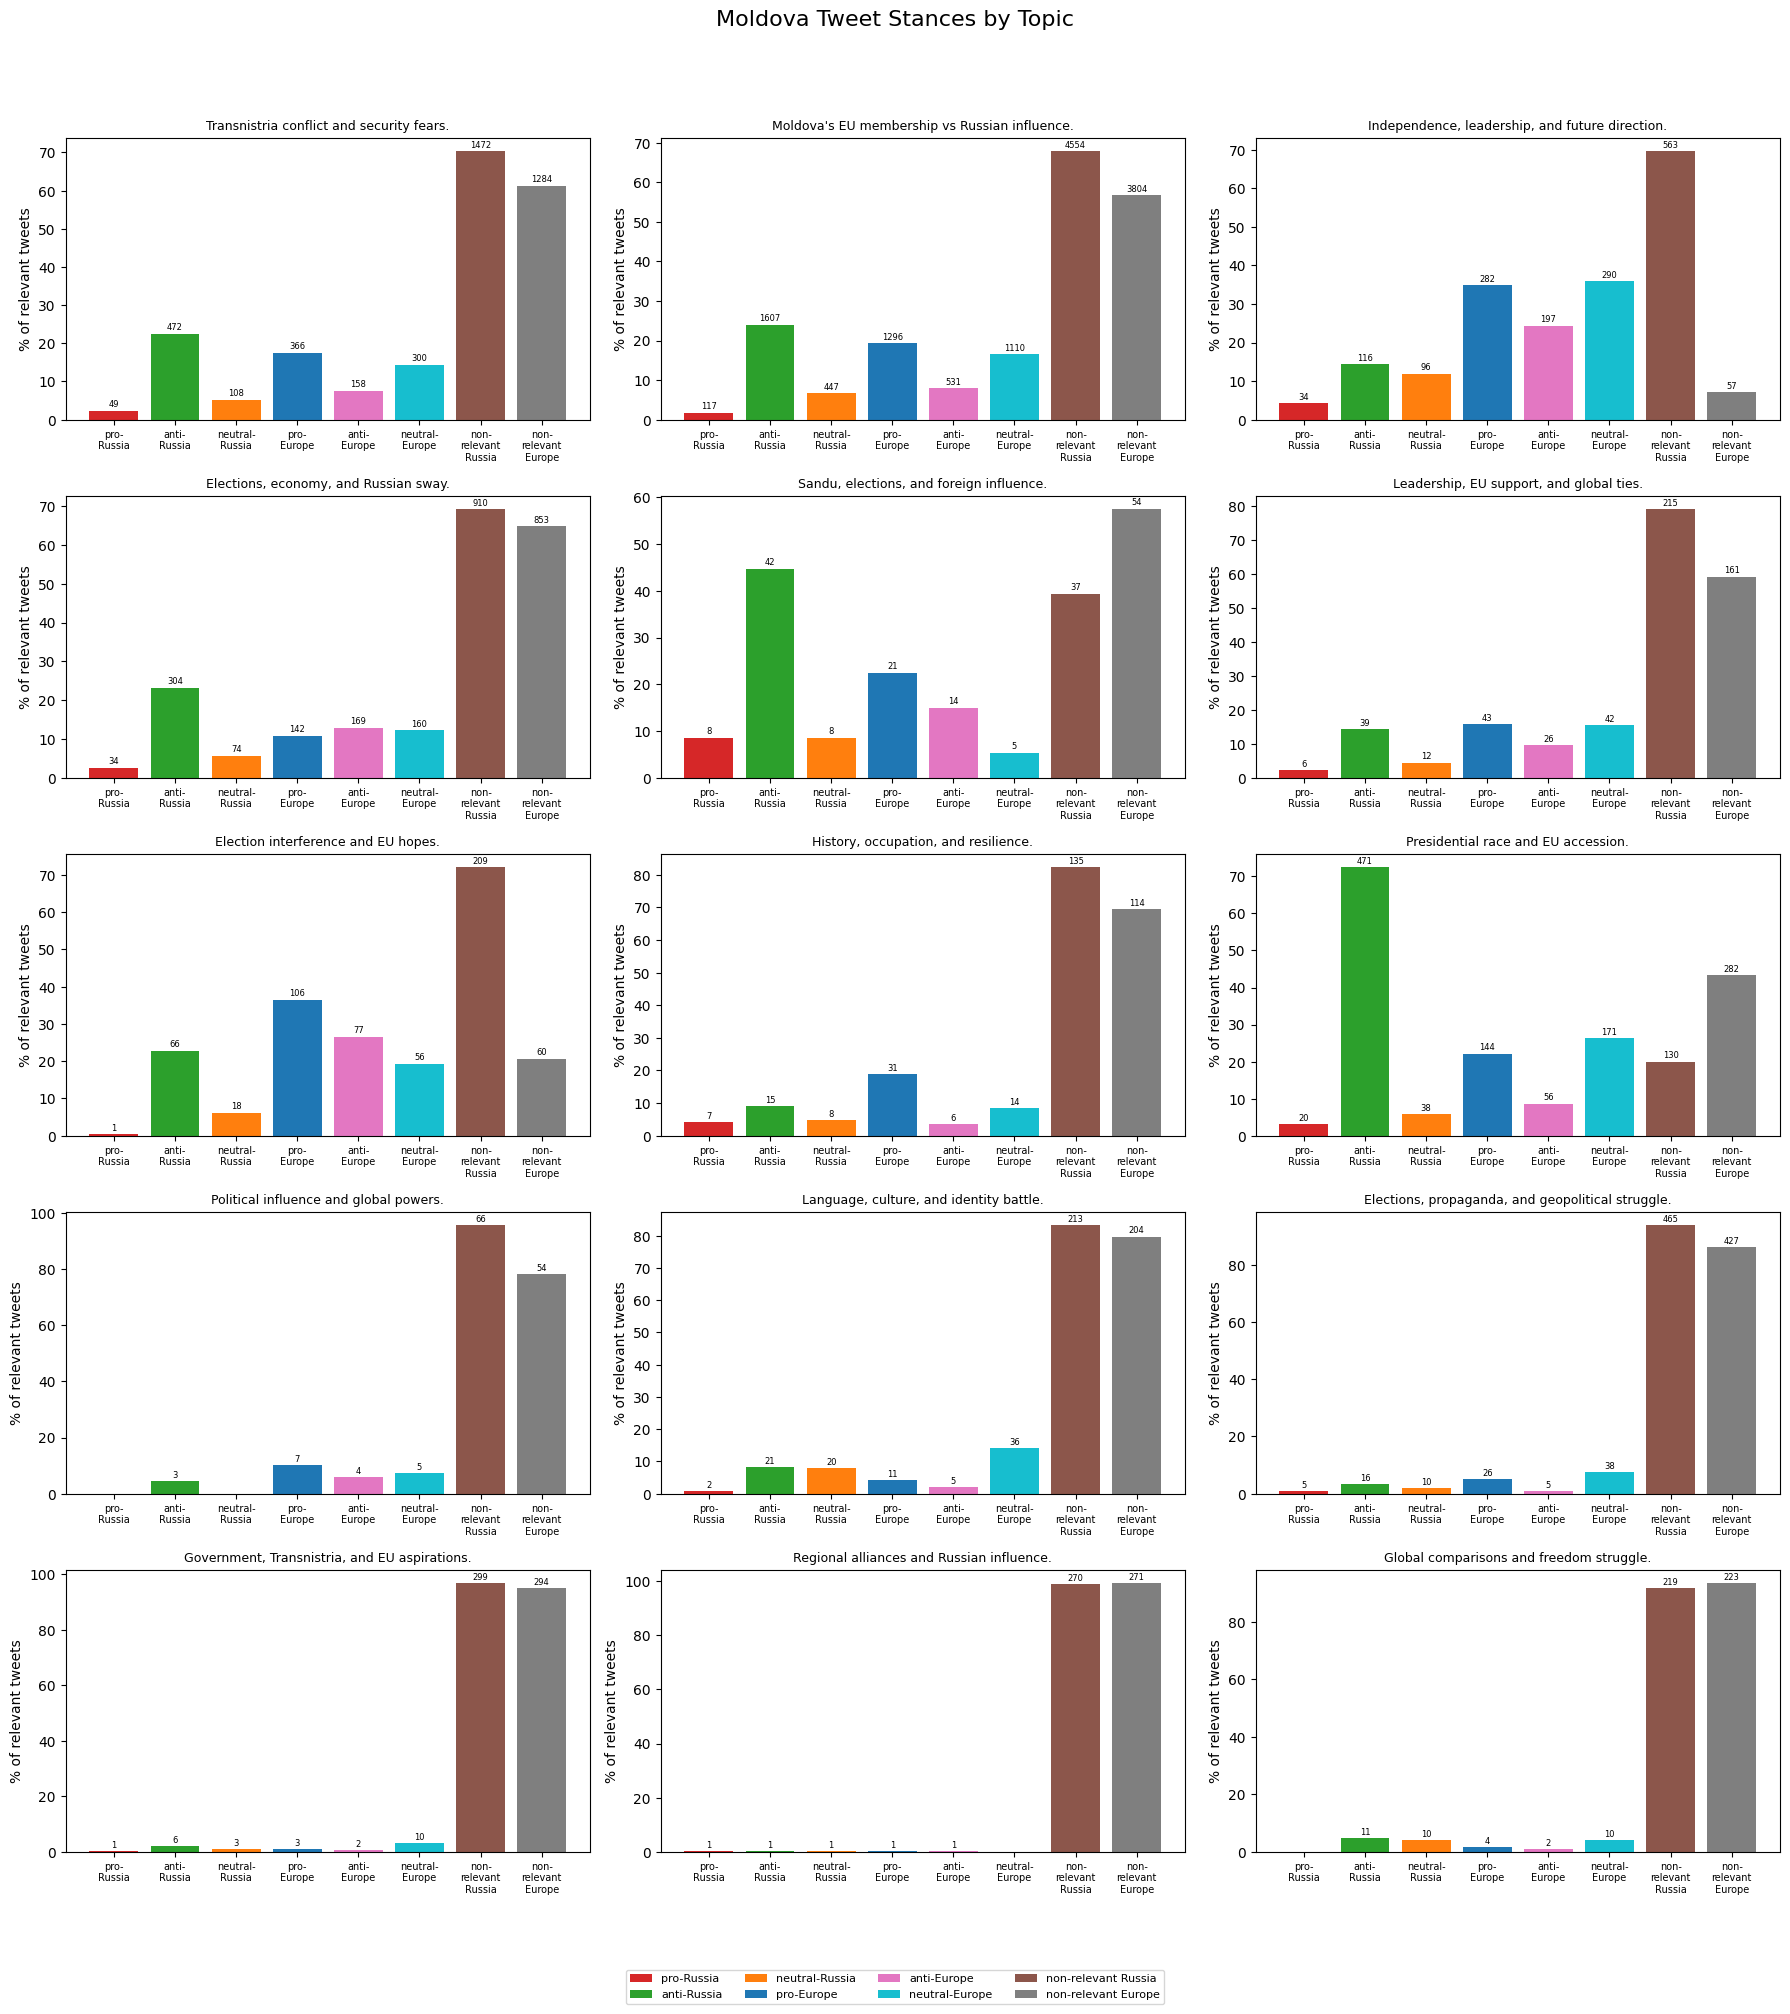

In [44]:
# Simplified Moldova stance visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Clean the data and prepare for analysis
df = gemini_df.dropna(subset=['Topic']).copy()

# Define stance columns in original order
stance_cols = ['pro-Russia', 'anti-Russia', 'neutral-Russia', 'pro-Europe', 
               'anti-Europe', 'neutral-Europe', 'non-relevant Russia', 'non-relevant Europe']

def calculate_stance_percentages_simple(df, stance_cols):
    """
    Simple calculation: For each topic and stance, what % of tweets are "yes"
    Uses only tweets that are relevant to that region (Russia or Europe)
    """
    results = []
    
    for topic in df['Topic'].unique():
        topic_df = df[df['Topic'] == topic].copy()
        
        for stance in stance_cols:
            #if 'Russia' in stance and stance != 'non-relevant Russia':
                # For Russia stances, only count tweets relevant to Russia
                #relevant_tweets = topic_df[topic_df['non-relevant Russia'] == 'no']
            #elif 'Europe' in stance and stance != 'non-relevant Europe':
                # For Europe stances, only count tweets relevant to Europe  
                #relevant_tweets = topic_df[topic_df['non-relevant Europe'] == 'no']
            #else:
                # For non-relevant columns, use all tweets
                #relevant_tweets = topic_df
            relevant_tweets = topic_df
            
            total_relevant = len(relevant_tweets)
            if total_relevant > 0:
                yes_count = (relevant_tweets[stance] == 'yes').sum()
                percentage = (yes_count / total_relevant) * 100
            else:
                yes_count = 0
                percentage = 0
            
            results.append({
                'Topic': topic,
                'Stance': stance,
                'Percentage': percentage,
                'Yes_Count': yes_count,
                'Total_Relevant': total_relevant
            })
    
    return pd.DataFrame(results)

def plot_stances_simple(pct_df, stance_cols):
    topics = pct_df['Topic'].unique()
    n_topics = len(topics)
    cols = 3
    rows = int(np.ceil(n_topics / cols))
    
    fig, axs = plt.subplots(rows, cols, figsize=(18, rows*4))
    if rows == 1:
        axs = [axs] if cols == 1 else axs
    else:
        axs = axs.flatten()
    
    # Color mapping maintaining original order
    colors = {
        'pro-Russia': '#d62728',           # Red
        'anti-Russia': '#2ca02c',          # Green  
        'neutral-Russia': '#ff7f0e',       # Orange
        'pro-Europe': '#1f77b4',           # Blue
        'anti-Europe': '#e377c2',          # Pink
        'neutral-Europe': '#17becf',       # Cyan
        'non-relevant Russia': '#8c564b',  # Brown
        'non-relevant Europe': '#7f7f7f'   # Gray
    }
    
    for i, topic in enumerate(topics):
        ax = axs[i]
        topic_data = pct_df[pct_df['Topic'] == topic]
        
        # Ensure data is in the same order as stance_cols
        topic_data = topic_data.set_index('Stance').reindex(stance_cols).reset_index()
        
        # Plot bars
        bars = ax.bar(range(len(stance_cols)), topic_data['Percentage'], 
                     color=[colors[stance] for stance in stance_cols])
        
        # Formatting
        ax.set_title(topic, fontsize=9, wrap=True)
        ax.set_xticks(range(len(stance_cols)))
        ax.set_xticklabels([s.replace('-', '-\n').replace(' ', '\n') for s in stance_cols], 
                          rotation=0, ha='center', fontsize=7)
        ax.set_ylabel('% of relevant tweets')
        
        # Add count labels on bars
        for j, (bar, yes_count, total_rel) in enumerate(zip(bars, topic_data['Yes_Count'], topic_data['Total_Relevant'])):
            if yes_count > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                       f'{yes_count}', ha='center', va='bottom', fontsize=6)
    
    # Hide unused subplots
    for j in range(len(topics), len(axs)):
        axs[j].set_visible(False)
    
    fig.suptitle('Moldova Tweet Stances by Topic', fontsize=16)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Add legend
    legend_elements = [plt.Rectangle((0,0),1,1, facecolor=colors[stance], label=stance) 
                      for stance in stance_cols]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, 
              bbox_to_anchor=(0.5, -0.02), fontsize=8)
    
    plt.show()

pct_df = calculate_stance_percentages_simple(df, stance_cols)
plot_stances_simple(pct_df, stance_cols)

In [45]:
# Sanity Check
print(len(gemini_df[gemini_df['topic'] == 14.0]))
print(len(gemini_df[gemini_df['Topic'] == 'Regional alliances and Russian influence.']))
print(len(moldova_df[moldova_df['topic'] == 14.0]))

69
153


In [53]:
def calculate_overall_sentiment_data(df):
    russia_stances = ['pro-Russia', 'anti-Russia', 'neutral-Russia']
    europe_stances = ['pro-Europe', 'anti-Europe', 'neutral-Europe']
    
    # RUSSIA ANALYSIS - across all tweets
    russia_relevant = df[df['non-relevant Russia'] == 'no']
    russia_total = len(russia_relevant)
    
    russia_percentages = []
    russia_counts = []
    
    for stance in russia_stances:
        yes_count = (russia_relevant[stance] == 'yes').sum()
        percentage = (yes_count / russia_total) * 100 if russia_total > 0 else 0
        russia_percentages.append(percentage)
        russia_counts.append(yes_count)
    
    # EUROPE ANALYSIS - across all tweets  
    europe_relevant = df[df['non-relevant Europe'] == 'no']
    europe_total = len(europe_relevant)
    
    europe_percentages = []
    europe_counts = []
    
    for stance in europe_stances:
        yes_count = (europe_relevant[stance] == 'yes').sum()
        percentage = (yes_count / europe_total) * 100 if europe_total > 0 else 0
        europe_percentages.append(percentage)
        europe_counts.append(yes_count)
    
    # Return results
    russia_results = {
        'stance': russia_stances,
        'counts': russia_counts, 
        'percentages': russia_percentages,
        'total': russia_total
    }
    
    europe_results = {
        'stance': europe_stances,
        'counts': europe_counts,
        'percentages': europe_percentages, 
        'total': europe_total
    }
    
    return russia_results, europe_results

def plot_overall_sentiment_charts(russia_results, europe_results):
    """
    Create two charts showing overall sentiment breakdown using pre-calculated data
    """
    russia_colors = ['#d62728', '#2ca02c', '#ff7f0e']  # Red, Green, Orange
    europe_colors = ['#1f77b4', '#e377c2', '#17becf']  # Blue, Pink, Cyan
    
    # Create figure with 2 subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot Russia chart
    bars1 = ax1.bar(russia_results['stance'], russia_results['percentages'], color=russia_colors)
    ax1.set_title(f'Russia Sentiment Distribution\n(n={russia_results["total"]:,} Russia-relevant tweets)', fontsize=12)
    ax1.set_ylabel('% of Russia-relevant tweets')
    ax1.set_ylim(0, max(100, max(russia_results['percentages']) * 1.1) if max(russia_results['percentages']) > 0 else 10)
    ax1.set_xticklabels([s.replace('-', '-\n') for s in russia_results['stance']], fontsize=10)
    
    # Add count and percentage labels on Russia bars
    for bar, count, pct in zip(bars1, russia_results['counts'], russia_results['percentages']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(russia_results['percentages'])*0.02, 
                f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Plot Europe chart
    bars2 = ax2.bar(europe_results['stance'], europe_results['percentages'], color=europe_colors)
    ax2.set_title(f'Europe Sentiment Distribution\n(n={europe_results["total"]:,} Europe-relevant tweets)', fontsize=12)
    ax2.set_ylabel('% of Europe-relevant tweets')
    ax2.set_ylim(0, max(100, max(europe_results['percentages']) * 1.1) if max(europe_results['percentages']) > 0 else 10)
    ax2.set_xticklabels([s.replace('-', '-\n') for s in europe_results['stance']], fontsize=10)
    
    # Add count and percentage labels on Europe bars
    for bar, count, pct in zip(bars2, europe_results['counts'], europe_results['percentages']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(europe_results['percentages'])*0.02, 
                f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

/var/folders/3w/vvw1yxs54zx1fq0z5kdrv0sw0000gn/T/ipykernel_69448/3696592133.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([s.replace('-', '-\n') for s in russia_results['stance']], fontsize=10)
/var/folders/3w/vvw1yxs54zx1fq0z5kdrv0sw0000gn/T/ipykernel_69448/3696592133.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([s.replace('-', '-\n') for s in europe_results['stance']], fontsize=10)


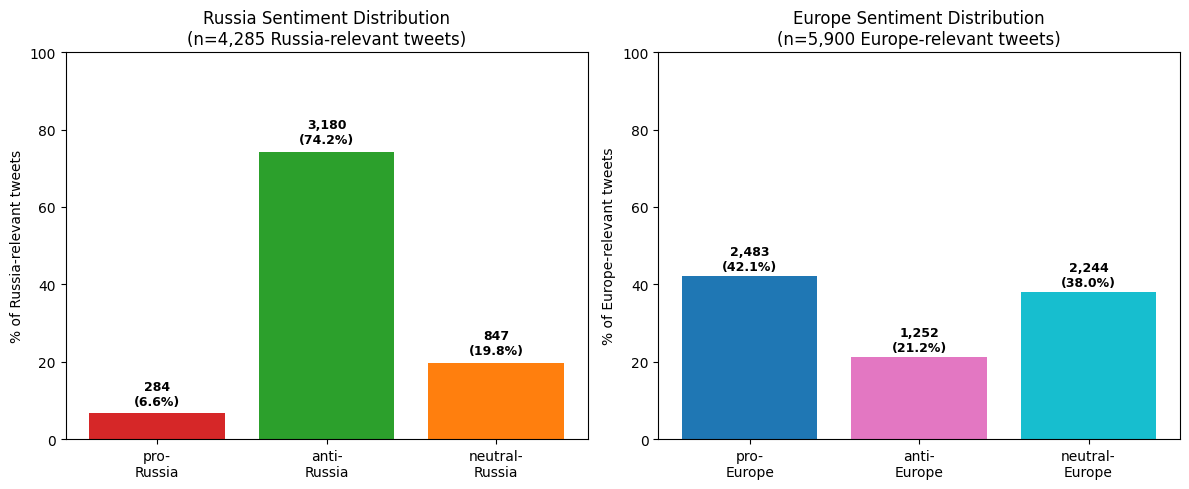

In [54]:

russia_data, europe_data = calculate_overall_sentiment_data(df)

plot_overall_sentiment_charts(russia_data, europe_data)

In [ ]:
# Gemini response sometimes counting YES across multiple columns, leading to > 100% total

In [71]:
moldova_df.columns

Index(['embeddedUrls', 'imageUrls', 'author', 'geolocation', 'id', 'language',
       'mediaType', 'name', 'timePublished', 'title', 'translatedTitle', 'url',
       'ContentText', 'providerName', 'emotions', 'Admiration', 'Anger',
       'Approval', 'Curiosity', 'Disgust', 'Fear', 'Joy', 'Love', 'Optimism',
       'Pessimism', 'Sadness', 'twitterData.mentionedUsers',
       'twitterData.engagementParentId', 'twitterData.engagementType',
       'twitterData.followerCount', 'twitterData.followingCount',
       'twitterData.likeCount', 'twitterData.retweetCount',
       'twitterData.tweetId', 'twitterData.twitterAuthorScreenname',
       'twitterData.twitterUserId', 'redditData.author',
       'redditData.authorAwardeeKarma', 'redditData.authorAwarderKarma',
       'redditData.authorKarma', 'redditData.comments',
       'redditData.engagementType', 'redditData.parentPostId',
       'redditData.redditPostId', 'redditData.subreddit',
       'redditData.subredditSubscribers', 'redditData.up

NEW GEMINI RESPONSE (WITH TWITTER IDS)

In [1]:
import json

# Load the JSON file
with open('labeled_data.json', 'r', encoding='utf-8') as f:
    labeled_list = json.load(f)

len(labeled_list)

16200

In [49]:
# Define stance columns in original order
cols = ['pro-Russia', 'anti-Russia', 'neutral-Russia', 'pro-Europe', 
               'anti-Europe', 'neutral-Europe', 'non-relevant Russia', 'non-relevant Europe', 'text', 'tweetId', 'index']

In [50]:
gemini_df = pd.DataFrame(labeled_list, columns=cols)

In [51]:
gemini_df.head(5)

,pro-Russia,anti-Russia,neutral-Russia,pro-Europe,anti-Europe,neutral-Europe,non-relevant Russia,non-relevant Europe,text,tweetId,index
0,no,yes,no,yes,no,no,no,no,"@Sonarrow_osint President since 2020, Maia San...",1845900399582031872,0.0
1,no,no,no,yes,no,no,yes,no,"""The road to European integration remains a di...",NA,1.0
2,no,no,no,no,yes,no,yes,no,@Petrasandu @whitenights_ro day to bet 10k wit...,1845893584085512448,2.0
3,no,no,no,no,no,no,yes,yes,And there is nothing to add!.,1845888373703020800,3.0
4,no,no,no,no,no,no,yes,yes,@NATO Is an Obsolete WAR MACHINE - @RichiMedhu...,1845848923463938048,4.0


In [52]:
stance_cols = ['pro-Russia', 'anti-Russia', 'neutral-Russia', 'pro-Europe', 'anti-Europe', 'neutral-Europe', 'non-relevant Russia', 'non-relevant Europe']

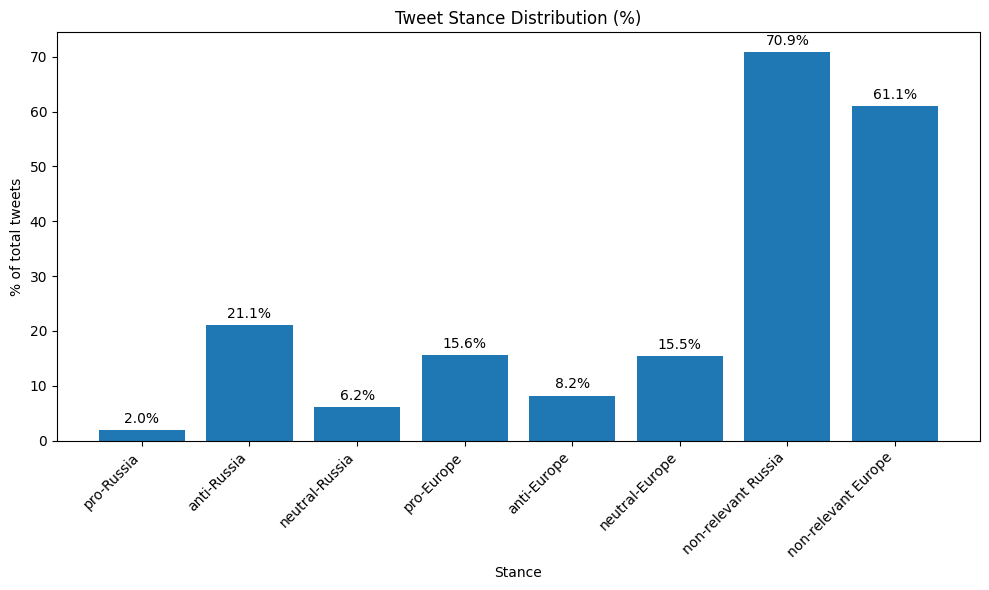

In [53]:
import matplotlib.pyplot as plt

# Calculate mask, counts, and percents
yes_mask = gemini_df[stance_cols].apply(lambda col: col.astype(str).str.lower() == "yes")
counts = yes_mask.sum()
percents = counts / len(gemini_df) * 100

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(percents.index, percents.values)

# Add percentage labels on top
ax.bar_label(bars, fmt='%.1f%%', padding=3)

ax.set_ylabel("% of total tweets")
ax.set_xlabel("Stance")
ax.set_title("Tweet Stance Distribution (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig('tweet_stance_distribution.png')
plt.show()

In [54]:
gemini_df.head(5)

,pro-Russia,anti-Russia,neutral-Russia,pro-Europe,anti-Europe,neutral-Europe,non-relevant Russia,non-relevant Europe,text,tweetId,index
0,no,yes,no,yes,no,no,no,no,"@Sonarrow_osint President since 2020, Maia San...",1845900399582031872,0.0
1,no,no,no,yes,no,no,yes,no,"""The road to European integration remains a di...",NA,1.0
2,no,no,no,no,yes,no,yes,no,@Petrasandu @whitenights_ro day to bet 10k wit...,1845893584085512448,2.0
3,no,no,no,no,no,no,yes,yes,And there is nothing to add!.,1845888373703020800,3.0
4,no,no,no,no,no,no,yes,yes,@NATO Is an Obsolete WAR MACHINE - @RichiMedhu...,1845848923463938048,4.0


In [59]:
match = moldova_df[moldova_df["translatedContentText"].str.contains("The road to European integration remains a di")]

In [66]:
print(moldova_df.columns)

Index(['embeddedUrls', 'imageUrls', 'author', 'geolocation', 'id', 'language',
       'mediaType', 'name', 'timePublished', 'title', 'translatedTitle', 'url',
       'ContentText', 'providerName', 'emotions', 'Admiration', 'Anger',
       'Approval', 'Curiosity', 'Disgust', 'Fear', 'Joy', 'Love', 'Optimism',
       'Pessimism', 'Sadness', 'twitterData.mentionedUsers',
       'twitterData.engagementParentId', 'twitterData.engagementType',
       'twitterData.followerCount', 'twitterData.followingCount',
       'twitterData.likeCount', 'twitterData.retweetCount',
       'twitterData.tweetId', 'twitterData.twitterAuthorScreenname',
       'twitterData.twitterUserId', 'redditData.author',
       'redditData.authorAwardeeKarma', 'redditData.authorAwarderKarma',
       'redditData.authorKarma', 'redditData.comments',
       'redditData.engagementType', 'redditData.parentPostId',
       'redditData.redditPostId', 'redditData.subreddit',
       'redditData.subredditSubscribers', 'redditData.up

In [211]:
df = pd.read_csv(".gitignore/moldova_new.csv")

In [256]:
print(df["ContentText"].isna().sum())
print(df["translatedContentText"].isna().sum())

8577
8577


In [212]:
len(df)

52815

In [216]:
moldova_df = pd.concat([df, placeholder_df])

In [229]:
# Simple check: verify all referenced parent IDs now exist
all_tweet_ids = set(moldova_df['twitterData.tweetId'].dropna())
all_parent_refs = set(moldova_df['twitterData.engagementParentId'].dropna())

# This should be empty if every orphan now has a parent
still_missing = all_parent_refs - all_tweet_ids

print(f"Missing parents after adding placeholders: {len(still_missing)}")
if still_missing:
    print(f"Still missing IDs: {list(still_missing)[:10]}")  # show first 10
else:
    print("✓ All orphans now have parents!")

Missing parents after adding placeholders: 0
✓ All orphans now have parents!


In [248]:
moldova_df["is_retweet"].isna().sum()

17154

In [ ]:
moldova_df = moldova_df.dropna(subset="translatedContentText")
moldova_df['is_retweet'] = moldova_df['ContentText'].apply(lambda x: x[:2]=='RT')
# moldova_df['is_retweet'].sum()  # number of retweets

In [258]:
moldova_df['is_retweet'].value_counts()

is_retweet
True     36615
False    16200
Name: count, dtype: int64

In [260]:
moldova_df["twitterData.engagementType"].value_counts(dropna=False)

twitterData.engagementType
retweet    36610
NaN         7120
reply       4192
tweet       4011
quote        882
Name: count, dtype: int64

In [ ]:
moldova_df_no_retweets = moldova_df[moldova_df["is_retweet"] == False]

In [244]:
# Count the number of rows without retweets
len(moldova_df_no_retweets)


16200

In [261]:
stances_df = gemini_df.reset_index(drop=True).join(moldova_df_no_retweets.reset_index(drop=True))

In [226]:
stances_df.columns

Index(['pro-Russia', 'anti-Russia', 'neutral-Russia', 'pro-Europe',
       'anti-Europe', 'neutral-Europe', 'non-relevant Russia',
       'non-relevant Europe', 'text', 'tweetId', 'index', 'embeddedUrls',
       'imageUrls', 'author', 'geolocation', 'id', 'language', 'mediaType',
       'name', 'timePublished', 'title', 'translatedTitle', 'url',
       'ContentText', 'providerName', 'emotions', 'Admiration', 'Anger',
       'Approval', 'Curiosity', 'Disgust', 'Fear', 'Joy', 'Love', 'Optimism',
       'Pessimism', 'Sadness', 'twitterData.mentionedUsers',
       'twitterData.engagementParentId', 'twitterData.engagementType',
       'twitterData.followerCount', 'twitterData.followingCount',
       'twitterData.likeCount', 'twitterData.retweetCount',
       'twitterData.tweetId', 'twitterData.twitterAuthorScreenname',
       'twitterData.twitterUserId', 'redditData.author',
       'redditData.authorAwardeeKarma', 'redditData.authorAwarderKarma',
       'redditData.authorKarma', 'redditData

In [262]:
def calculate_overall_sentiment_data(df):
    russia_stances = ['pro-Russia', 'anti-Russia', 'neutral-Russia']
    europe_stances = ['pro-Europe', 'anti-Europe', 'neutral-Europe']
    
    # RUSSIA ANALYSIS - across all tweets
    russia_relevant = df[df['non-relevant Russia'] == 'no']
    russia_total = len(russia_relevant)
    
    russia_percentages = []
    russia_counts = []
    
    for stance in russia_stances:
        yes_count = (russia_relevant[stance] == 'yes').sum()
        percentage = (yes_count / russia_total) * 100 if russia_total > 0 else 0
        russia_percentages.append(percentage)
        russia_counts.append(yes_count)
    
    # EUROPE ANALYSIS - across all tweets  
    europe_relevant = df[df['non-relevant Europe'] == 'no']
    europe_total = len(europe_relevant)
    
    europe_percentages = []
    europe_counts = []
    
    for stance in europe_stances:
        yes_count = (europe_relevant[stance] == 'yes').sum()
        percentage = (yes_count / europe_total) * 100 if europe_total > 0 else 0
        europe_percentages.append(percentage)
        europe_counts.append(yes_count)
    
    # Return results
    russia_results = {
        'stance': russia_stances,
        'counts': russia_counts, 
        'percentages': russia_percentages,
        'total': russia_total
    }
    
    europe_results = {
        'stance': europe_stances,
        'counts': europe_counts,
        'percentages': europe_percentages, 
        'total': europe_total
    }
    
    return russia_results, europe_results

def plot_overall_sentiment_charts(russia_results, europe_results):
    """
    Create two charts showing overall sentiment breakdown using pre-calculated data
    """
    russia_colors = ['#d62728', '#2ca02c', '#ff7f0e']  # Red, Green, Orange
    europe_colors = ['#1f77b4', '#e377c2', '#17becf']  # Blue, Pink, Cyan
    
    # Create figure with 2 subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot Russia chart
    bars1 = ax1.bar(russia_results['stance'], russia_results['percentages'], color=russia_colors)
    ax1.set_title(f'Russia Sentiment Distribution\n(n={russia_results["total"]:,} Russia-relevant tweets)', fontsize=12)
    ax1.set_ylabel('% of Russia-relevant tweets')
    ax1.set_ylim(0, max(100, max(russia_results['percentages']) * 1.1) if max(russia_results['percentages']) > 0 else 10)
    ax1.set_xticklabels([s.replace('-', '-\n') for s in russia_results['stance']], fontsize=10)
    
    # Add count and percentage labels on Russia bars
    for bar, count, pct in zip(bars1, russia_results['counts'], russia_results['percentages']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(russia_results['percentages'])*0.02, 
                f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Plot Europe chart
    bars2 = ax2.bar(europe_results['stance'], europe_results['percentages'], color=europe_colors)
    ax2.set_title(f'Europe Sentiment Distribution\n(n={europe_results["total"]:,} Europe-relevant tweets)', fontsize=12)
    ax2.set_ylabel('% of Europe-relevant tweets')
    ax2.set_ylim(0, max(100, max(europe_results['percentages']) * 1.1) if max(europe_results['percentages']) > 0 else 10)
    ax2.set_xticklabels([s.replace('-', '-\n') for s in europe_results['stance']], fontsize=10)
    
    # Add count and percentage labels on Europe bars
    for bar, count, pct in zip(bars2, europe_results['counts'], europe_results['percentages']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(europe_results['percentages'])*0.02, 
                f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig("stance distribution by relevance.png")
    plt.show()

/var/folders/3w/vvw1yxs54zx1fq0z5kdrv0sw0000gn/T/ipykernel_94716/4162586508.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([s.replace('-', '-\n') for s in russia_results['stance']], fontsize=10)
/var/folders/3w/vvw1yxs54zx1fq0z5kdrv0sw0000gn/T/ipykernel_94716/4162586508.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([s.replace('-', '-\n') for s in europe_results['stance']], fontsize=10)


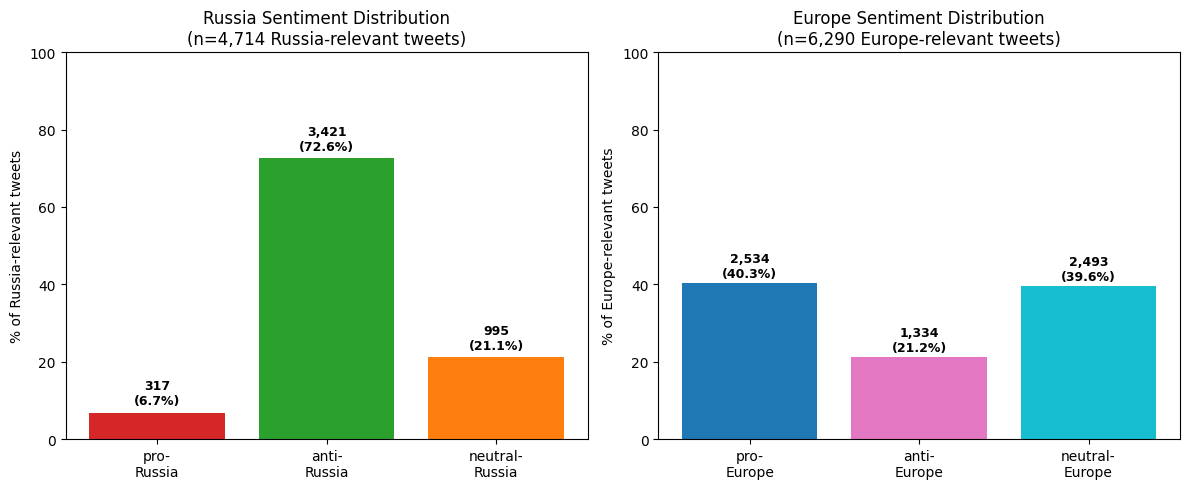

In [263]:

russia_data, europe_data = calculate_overall_sentiment_data(stances_df)

plot_overall_sentiment_charts(russia_data, europe_data)

In [106]:
stances_df.columns

Index(['pro-Russia', 'anti-Russia', 'neutral-Russia', 'pro-Europe',
       'anti-Europe', 'neutral-Europe', 'non-relevant Russia',
       'non-relevant Europe', 'text', 'tweetId', 'index', 'embeddedUrls',
       'imageUrls', 'author', 'geolocation', 'id', 'language', 'mediaType',
       'name', 'timePublished', 'title', 'translatedTitle', 'url',
       'ContentText', 'providerName', 'emotions', 'Admiration', 'Anger',
       'Approval', 'Curiosity', 'Disgust', 'Fear', 'Joy', 'Love', 'Optimism',
       'Pessimism', 'Sadness', 'twitterData.mentionedUsers',
       'twitterData.engagementParentId', 'twitterData.engagementType',
       'twitterData.followerCount', 'twitterData.followingCount',
       'twitterData.likeCount', 'twitterData.retweetCount',
       'twitterData.tweetId', 'twitterData.twitterAuthorScreenname',
       'twitterData.twitterUserId', 'redditData.author',
       'redditData.authorAwardeeKarma', 'redditData.authorAwarderKarma',
       'redditData.authorKarma', 'redditData

/Users/osman/miniconda3/envs/moldova-elections-fixed/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/osman/miniconda3/envs/moldova-elections-fixed/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/osman/miniconda3/envs/moldova-elections-fixed/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/osman/miniconda3/envs/mo

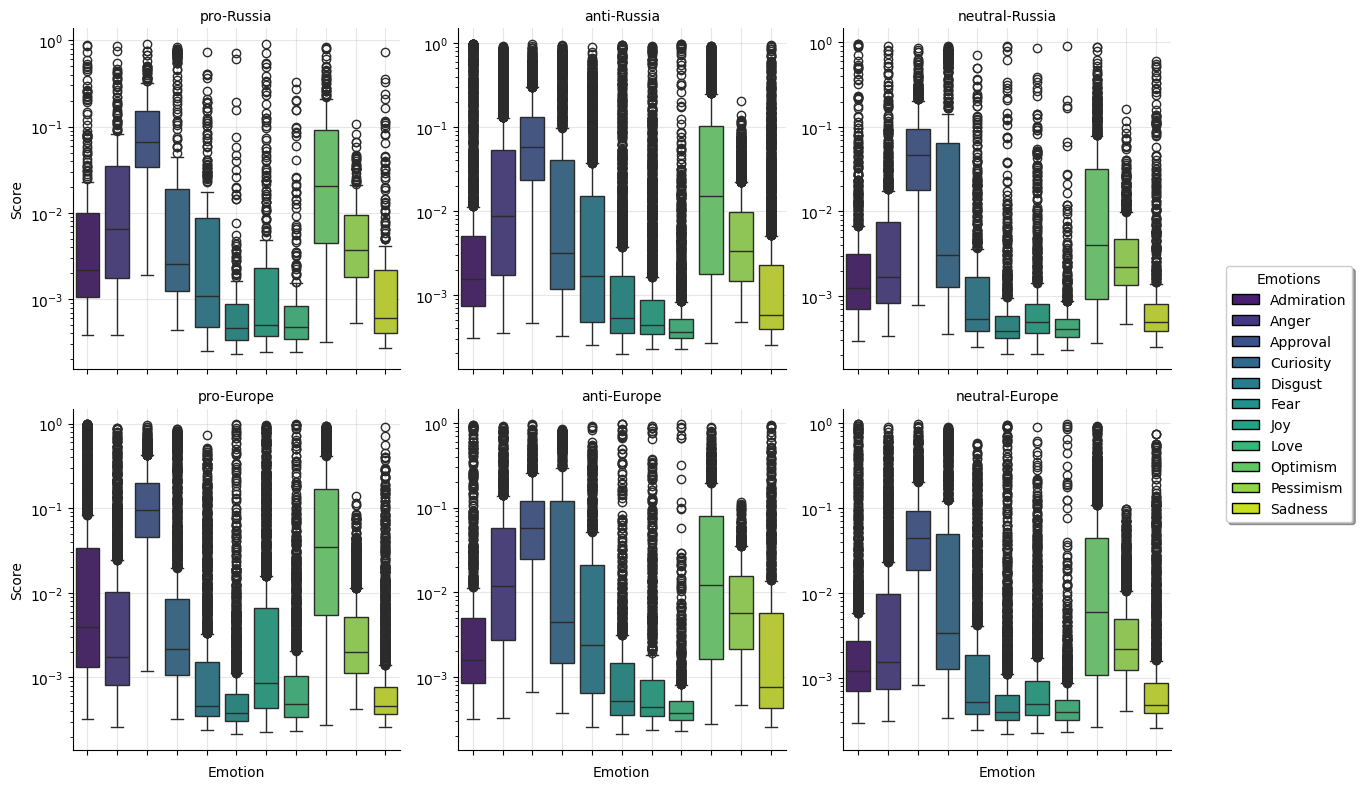

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# Define the stance and emotion columns based on your dataset
stance_cols = ['pro-Russia', 'anti-Russia', 'neutral-Russia', 'pro-Europe', 'anti-Europe', 'neutral-Europe']
emotion_cols = ['Admiration', 'Anger', 'Approval', 'Curiosity', 'Disgust', 'Fear', 'Joy', 'Love', 'Optimism', 'Pessimism', 'Sadness']

# Create a list to store dataframes for each stance
stance_dfs = []

for stance in stance_cols:
    # Get rows where this stance is "yes" (case insensitive)
    stance_mask = stances_df[stance].astype(str).str.lower() == "yes"
    
    if stance_mask.sum() > 0:  # Only process if there are matching rows
        # Select emotion columns for these rows and add stance label
        stance_emotions = stances_df.loc[stance_mask, emotion_cols].copy()
        stance_emotions['Stance'] = stance
        stance_dfs.append(stance_emotions)

# Combine all stance dataframes
if stance_dfs:  # Check if we have any data
    df_combined = pd.concat(stance_dfs, ignore_index=True)
    
    # Melt the dataframe to long format
    df_melted = df_combined.melt(
        id_vars="Stance",
        value_vars=emotion_cols,
        var_name="Emotion",
        value_name="Score"
    )
    
    # Convert Score to numeric, handling any non-numeric values
    df_melted['Score'] = pd.to_numeric(df_melted['Score'], errors='coerce')
    
    # Remove rows with NaN scores or scores <= 0 (for log scale)
    df_melted = df_melted.dropna(subset=['Score'])
    df_melted = df_melted[df_melted['Score'] > 0]
    
    # Create color palette for emotions
    colors = sns.color_palette("viridis", len(emotion_cols))
    emotion_colors = dict(zip(emotion_cols, colors))
    
    # Create the plot
    g = sns.FacetGrid(df_melted, col="Stance", col_wrap=3, height=4, sharey=False)
    g.map_dataframe(
        sns.boxplot,
        x="Emotion", y="Score", 
        palette=emotion_colors,
        order=emotion_cols
    )
    
    # Customize each subplot
    for ax in g.axes.flat:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.3f}"))
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)
    
    g.set_titles("{col_name}")
    
    # Create legend for emotion colors
    legend_elements = [plt.Rectangle((0,0),1,1, facecolor=emotion_colors[emotion], 
                                   edgecolor='black', label=emotion) 
                      for emotion in emotion_cols]
    
    # Add legend to the figure
    g.fig.legend(handles=legend_elements, 
                title="Emotions", 
                bbox_to_anchor=(1.02, 0.5), 
                loc='center left',
                frameon=True,
                fancybox=True,
                shadow=True)
    
    # Adjust layout to accommodate legend BEFORE saving
    plt.tight_layout()
    g.fig.subplots_adjust(right=0.98)  # Make room for legend on the right
    
    # Save with bbox_inches='tight' to include all elements
    plt.savefig("emotion_by_stance_log.png", dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    plt.show()
    
else:
    print("No data found matching the stance criteria. Please check your data and stance column values.")

In [109]:
stances_df['topic'].head(5)

0     1.0
1     0.0
2     1.0
3     8.0
4    29.0
Name: topic, dtype: float64

In [100]:
len(moldova_df)

16200

Summary of normalized stance data:
Total topics: 15
Topics: [1.0, 0.0, 8.0, 13.0, 7.0, 9.0, 12.0, 10.0, 4.0, 14.0, 6.0, 3.0, 2.0, 5.0, 11.0]

Verification - percentages should sum to ~100% within each region for each topic:
1.0: Russia=100.0%, Europe=100.0%
0.0: Russia=100.0%, Europe=100.0%
8.0: Russia=100.0%, Europe=100.0%
13.0: Russia=100.0%, Europe=100.0%
7.0: Russia=100.0%, Europe=100.0%
9.0: Russia=100.0%, Europe=100.0%
12.0: Russia=100.0%, Europe=100.0%
10.0: Russia=100.0%, Europe=100.0%
4.0: Russia=100.0%, Europe=100.0%
14.0: Russia=100.0%, Europe=100.0%
6.0: Russia=100.0%, Europe=100.0%
3.0: Russia=100.0%, Europe=100.0%
2.0: Russia=100.0%, Europe=100.0%
5.0: Russia=100.0%, Europe=100.0%
11.0: Russia=100.0%, Europe=100.0%


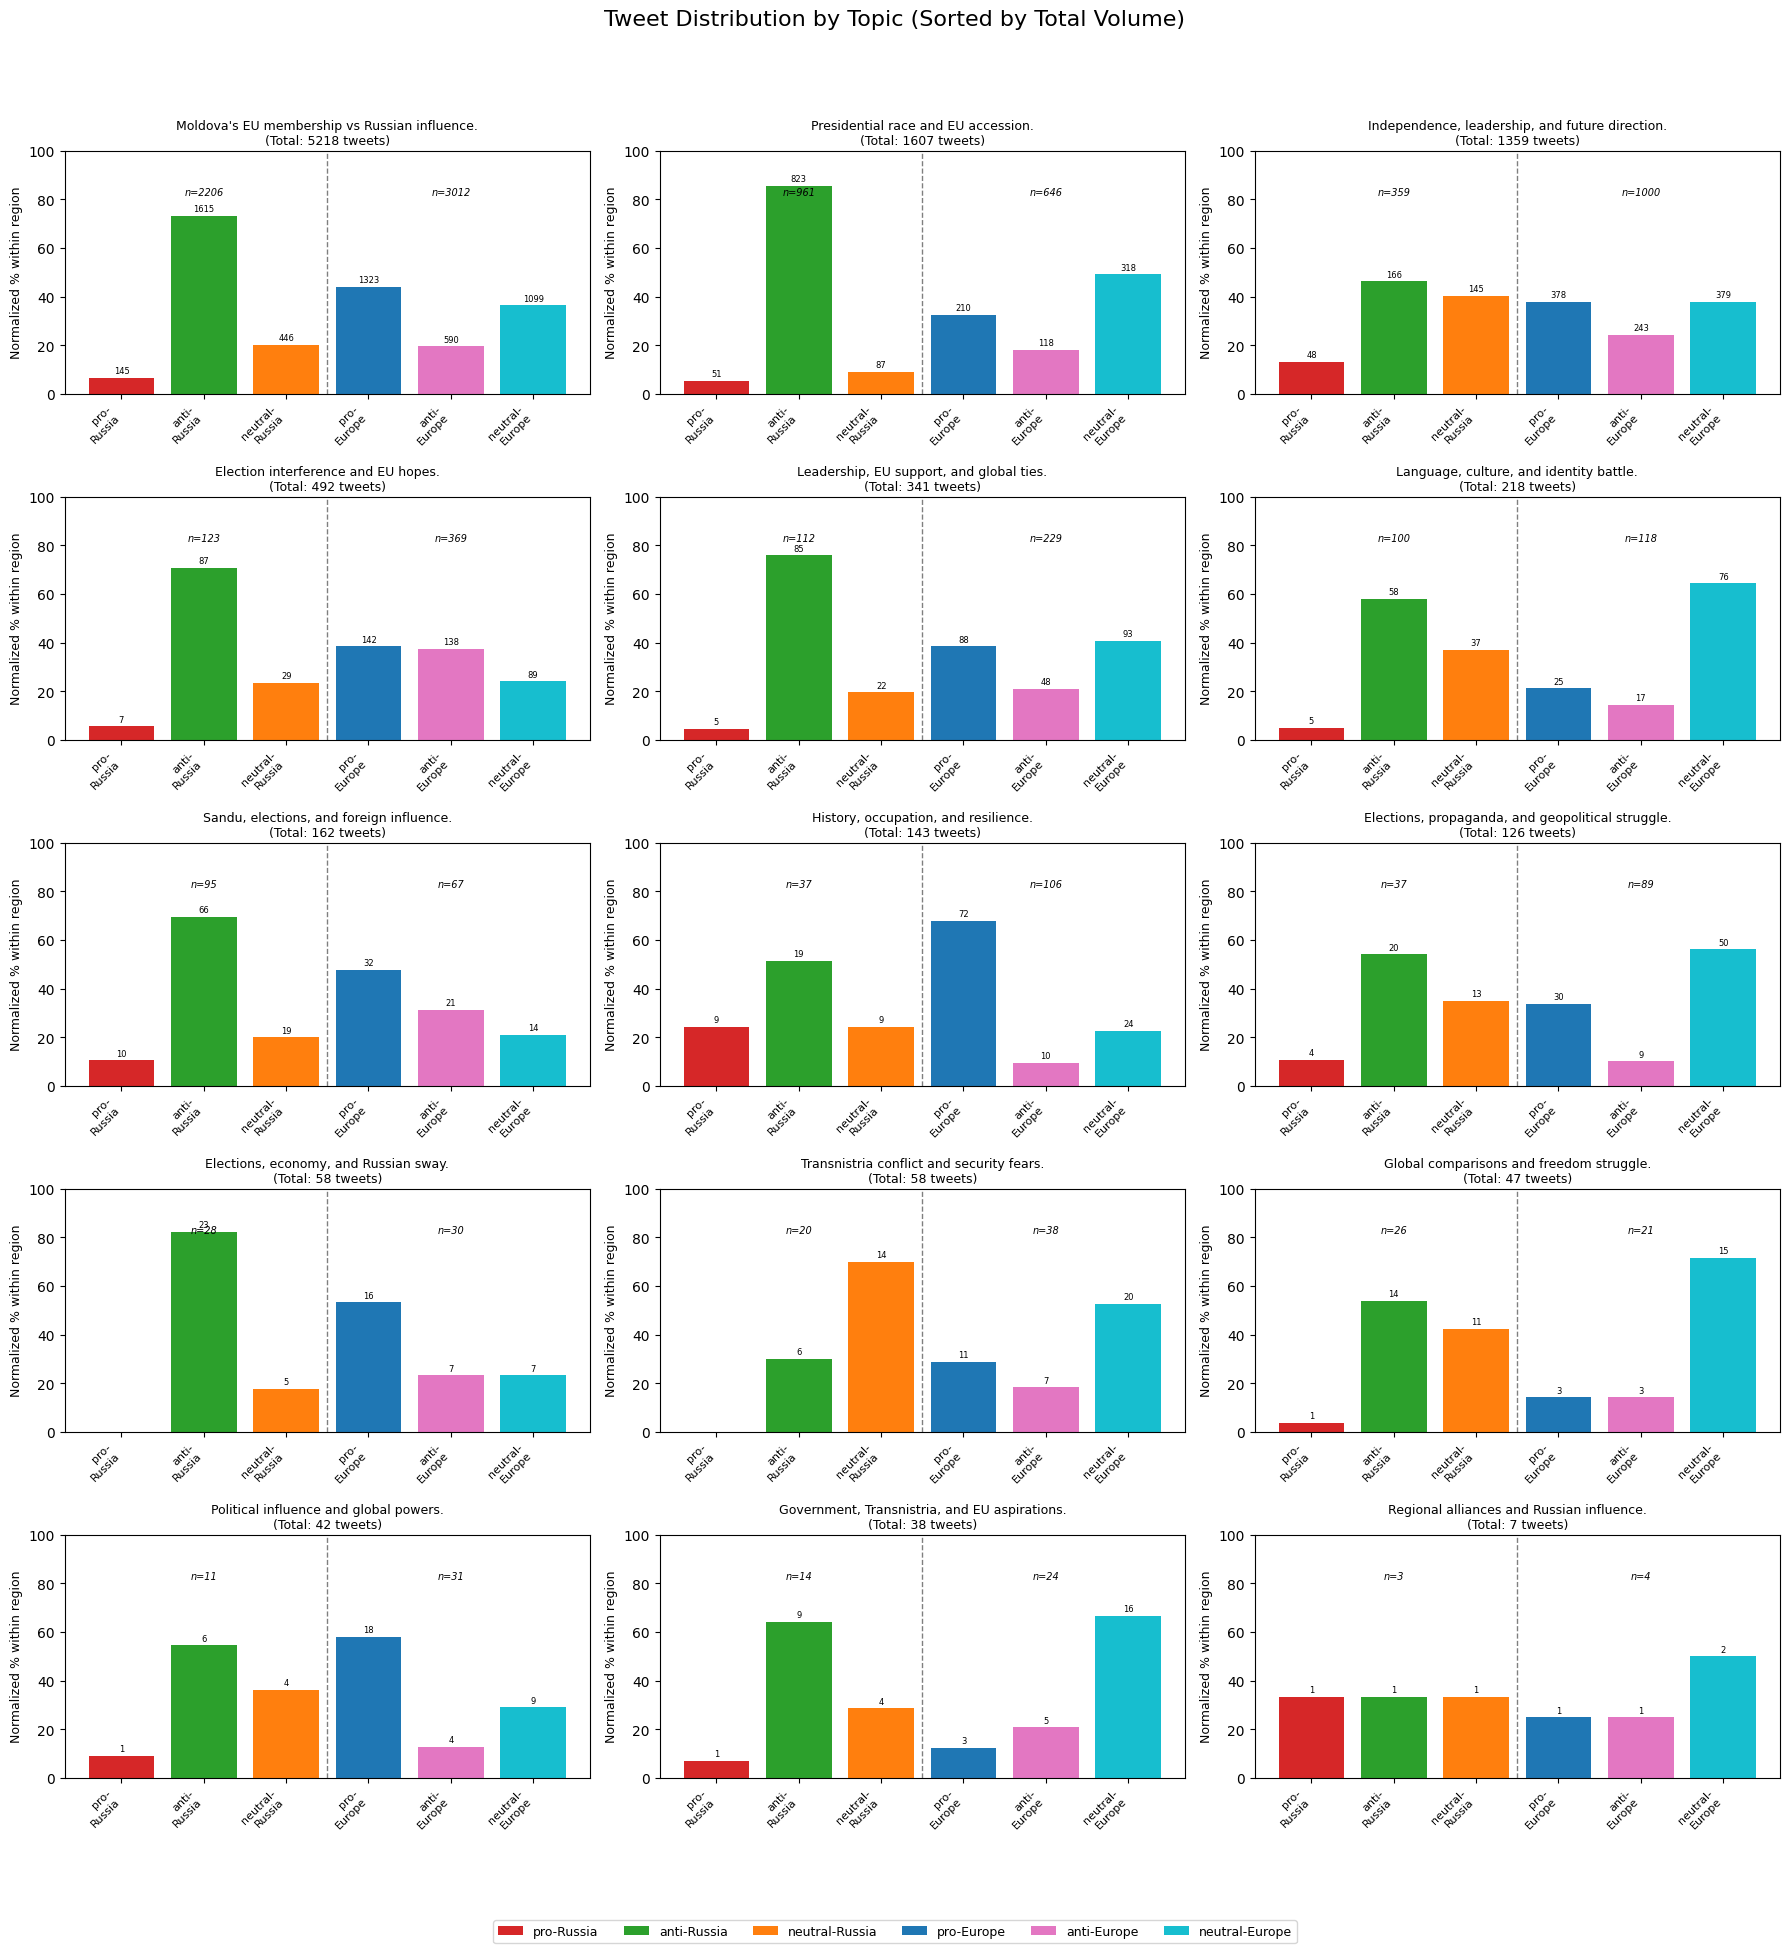

In [131]:
# Normalized Moldova stance visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Clean the data and prepare for analysis - updated for stances_df
df = stances_df.dropna(subset=['Topic']).copy()

# Filter to only include topics 0-14
df = df[df['Topic'].isin(range(15))].copy()

def calculate_normalized_stance_percentages(df, stance_cols):
    """
    Normalized calculation: For each topic, calculate stance percentages 
    that sum to 100% within each region (Russia/Europe)
    """
    results = []
    
    for topic in df['Topic'].unique():
        topic_df = df[df['Topic'] == topic].copy()
        
        # Separate Russia and Europe stances
        russia_stances = ['pro-Russia', 'anti-Russia', 'neutral-Russia']
        europe_stances = ['pro-Europe', 'anti-Europe', 'neutral-Europe']
        
        # Calculate for Russia stances
        russia_counts = {}
        for stance in russia_stances:
            russia_counts[stance] = (topic_df[stance] == 'yes').sum()
        
        russia_total = sum(russia_counts.values())
        
        # Calculate for Europe stances  
        europe_counts = {}
        for stance in europe_stances:
            europe_counts[stance] = (topic_df[stance] == 'yes').sum()
            
        europe_total = sum(europe_counts.values())
        
        # Add normalized percentages for Russia
        for stance in russia_stances:
            if russia_total > 0:
                percentage = (russia_counts[stance] / russia_total) * 100
            else:
                percentage = 0
                
            results.append({
                'Topic': topic,
                'Stance': stance,
                'Percentage': percentage,
                'Yes_Count': russia_counts[stance],
                'Total_Relevant': russia_total,
                'Region': 'Russia'
            })
        
        # Add normalized percentages for Europe
        for stance in europe_stances:
            if europe_total > 0:
                percentage = (europe_counts[stance] / europe_total) * 100
            else:
                percentage = 0
                
            results.append({
                'Topic': topic,
                'Stance': stance,
                'Percentage': percentage,
                'Yes_Count': europe_counts[stance],
                'Total_Relevant': europe_total,
                'Region': 'Europe'
            })
    
    return pd.DataFrame(results)

def plot_normalized_stances(pct_df, stance_cols):
    # Calculate total tweets per topic for sorting
    topic_totals = []
    for topic in pct_df['Topic'].unique():
        topic_data = pct_df[pct_df['Topic'] == topic]
        russia_total = topic_data[topic_data['Region'] == 'Russia']['Total_Relevant'].iloc[0]
        europe_total = topic_data[topic_data['Region'] == 'Europe']['Total_Relevant'].iloc[0]
        total_tweets = russia_total + europe_total
        topic_totals.append((topic, total_tweets))
    
    # Sort topics by total tweets (descending order - highest first)
    topic_totals.sort(key=lambda x: x[1], reverse=True)
    topics = [topic for topic, _ in topic_totals]
    
    n_topics = len(topics)
    cols = 3
    rows = int(np.ceil(n_topics / cols))
    
    fig, axs = plt.subplots(rows, cols, figsize=(18, rows*4))
    if rows == 1:
        axs = [axs] if cols == 1 else axs
    else:
        axs = axs.flatten()
    
    # Color mapping maintaining original order
    colors = {
        'pro-Russia': '#d62728',           # Red
        'anti-Russia': '#2ca02c',          # Green  
        'neutral-Russia': '#ff7f0e',       # Orange
        'pro-Europe': '#1f77b4',           # Blue
        'anti-Europe': '#e377c2',          # Pink
        'neutral-Europe': '#17becf'        # Cyan
    }
    
    for i, topic in enumerate(topics):
        ax = axs[i]
        topic_data = pct_df[pct_df['Topic'] == topic]
        
        # Ensure data is in the same order as stance_cols
        topic_data = topic_data.set_index('Stance').reindex(stance_cols).reset_index()
        
        # Plot bars
        bars = ax.bar(range(len(stance_cols)), topic_data['Percentage'], 
                     color=[colors[stance] for stance in stance_cols])
        
        # Get total tweets for this topic (for title)
        russia_total = topic_data[topic_data['Stance'].str.contains('Russia')]['Total_Relevant'].iloc[0]
        europe_total = topic_data[topic_data['Stance'].str.contains('Europe')]['Total_Relevant'].iloc[0]
        total_tweets = russia_total + europe_total
        
        # Formatting - use descriptive topic names with total count
        topic_name = moldova_topics[int(topic)] if int(topic) < len(moldova_topics) else f"Topic {topic}"
        ax.set_title(f'{topic_name}\n(Total: {total_tweets} tweets)', fontsize=9, wrap=True)
        ax.set_xticks(range(len(stance_cols)))
        ax.set_xticklabels([s.replace('-', '-\n') for s in stance_cols], 
                          rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Normalized % within region', fontsize=9)
        ax.set_ylim(0, 100)
        
        # Add vertical line to separate Russia and Europe stances
        ax.axvline(x=2.5, color='black', linestyle='--', alpha=0.5, linewidth=1)
        
        # Add count labels on bars
        for j, (bar, yes_count, total_rel) in enumerate(zip(bars, topic_data['Yes_Count'], topic_data['Total_Relevant'])):
            if yes_count > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                       f'{yes_count}', ha='center', va='bottom', fontsize=6)
        
        # Add regional totals
        ax.text(1, 85, f'n={russia_total}', ha='center', va='top', fontsize=7, style='italic')
        ax.text(4, 85, f'n={europe_total}', ha='center', va='top', fontsize=7, style='italic')
    
    # Hide unused subplots
    for j in range(len(topics), len(axs)):
        axs[j].set_visible(False)
    
    fig.suptitle('Tweet Distribution by Topic (Sorted by Total Volume)', fontsize=16)
    fig.tight_layout(rect=[0, 0.06, 1, 0.95])  
     
    # Add legend
    legend_elements = [plt.Rectangle((0,0),1,1, facecolor=colors[stance], label=stance) 
                      for stance in stance_cols]
    fig.legend(handles=legend_elements, loc='lower center', ncol=6, 
              bbox_to_anchor=(0.5, 0.01), fontsize=9)
    
    plt.savefig("normalized_moldova_stances_sorted.png", dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    plt.show()

# Calculate normalized percentages
pct_df = calculate_normalized_stance_percentages(df, stance_cols)

# Display summary statistics
print("Summary of normalized stance data:")
print(f"Total topics: {len(pct_df['Topic'].unique())}")
print(f"Topics: {list(pct_df['Topic'].unique())}")
print("\nVerification - percentages should sum to ~100% within each region for each topic:")
for topic in pct_df['Topic'].unique():
    topic_data = pct_df[pct_df['Topic'] == topic]
    russia_sum = topic_data[topic_data['Region'] == 'Russia']['Percentage'].sum()
    europe_sum = topic_data[topic_data['Region'] == 'Europe']['Percentage'].sum()
    print(f"{topic}: Russia={russia_sum:.1f}%, Europe={europe_sum:.1f}%")

# Plot the normalized stances
plot_normalized_stances(pct_df, stance_cols)

In [213]:
import pandas as pd
import re
from collections import Counter, defaultdict

# Ensure 'timePublished' is in datetime format if needed
if not pd.api.types.is_datetime64_any_dtype(df['timePublished']):
    df['timePublished'] = pd.to_datetime(df['timePublished'], unit='ms', errors='coerce')

# Step 1: Filter valid child tweets (with both tweetId and engagementParentId)
df_valid = df.dropna(subset=['twitterData.tweetId', 'twitterData.engagementParentId'])

# Step 2: Identify parent tweet IDs that are missing from dataset
existing_ids = set(df['twitterData.tweetId'].dropna())
referenced_ids = set(df_valid['twitterData.engagementParentId'])
missing_parents = referenced_ids - existing_ids

# Step 3: Get all rows referencing missing parent tweets
orphans = df_valid[df_valid['twitterData.engagementParentId'].isin(missing_parents)]

# Step 4: Build placeholder rows
placeholder_rows = []
grouped = orphans.groupby('twitterData.engagementParentId')

for pid, group in grouped:
    # Most common language and topic
    lang = Counter(group['language'].dropna()).most_common(1)
    topic = Counter(group['Topic'].dropna()).most_common(1)
    t = Counter(group['topic'].dropna()).most_common(1)

    # Try to extract content from retweets
    retweets = group[group['twitterData.engagementType'] == 'retweet']
    original_texts = []
    author_candidates = []

    for text in retweets['ContentText'].dropna():
        match = re.match(r'^RT\s+@(\w+):\s*(.*)', text)
        if match:
            print('aaa')
            author_candidates.append(match.group(1))  # screenname
            cleaned = match.group(2).strip()
            if cleaned:
                original_texts.append(cleaned)

    # Determine most common cleaned text and author
    content_text = Counter(original_texts).most_common(1)
    clean_text = content_text[0][0] if content_text else None

    original_author = Counter(author_candidates).most_common(1)
    author_name = original_author[0][0] if original_author else None

    group_times = group['timePublished'].dropna()
    oldest_time = group_times.min() if not group_times.empty else pd.NaT

    placeholder = {
        'twitterData.tweetId': pid,
        'language': lang[0][0] if lang else None,
        'Topic': topic[0][0] if topic else None,
        'topic': t[0][0] if t else None,
        'ContentText': clean_text,
        'cleanText': clean_text,
        'translatedContentText': clean_text,
        'author': f"@{author_name}" if author_name else None,
        'twitterData.twitterAuthorScreenname': author_name,
        'timePublished': oldest_time,
        'name': None,
        'twitterData.twitterUserId': None,
        'twitterData.engagementType': 'tweet',  # inferred as original
    }

    placeholder_rows.append(placeholder)

# Step 5: Create DataFrame and align columns
placeholder_df = pd.DataFrame(placeholder_rows)
placeholder_df = placeholder_df.reindex(columns=df.columns)  # ensure same structure


In [136]:
((stances_df["tweetId"] == "NA").sum()) / len(stances_df) * 100

38.05555555555556

In [137]:
stances_df.columns

Index(['pro-Russia', 'anti-Russia', 'neutral-Russia', 'pro-Europe',
       'anti-Europe', 'neutral-Europe', 'non-relevant Russia',
       'non-relevant Europe', 'text', 'tweetId', 'index', 'embeddedUrls',
       'imageUrls', 'author', 'geolocation', 'id', 'language', 'mediaType',
       'name', 'timePublished', 'title', 'translatedTitle', 'url',
       'ContentText', 'providerName', 'emotions', 'Admiration', 'Anger',
       'Approval', 'Curiosity', 'Disgust', 'Fear', 'Joy', 'Love', 'Optimism',
       'Pessimism', 'Sadness', 'twitterData.mentionedUsers',
       'twitterData.engagementParentId', 'twitterData.engagementType',
       'twitterData.followerCount', 'twitterData.followingCount',
       'twitterData.likeCount', 'twitterData.retweetCount',
       'twitterData.tweetId', 'twitterData.twitterAuthorScreenname',
       'twitterData.twitterUserId', 'redditData.author',
       'redditData.authorAwardeeKarma', 'redditData.authorAwarderKarma',
       'redditData.authorKarma', 'redditData

In [138]:
# total number of rows
total_rows = len(stances_df)

# mask for rows where translatedContentText is not null/NaN and not just whitespace
mask = (
    stances_df['translatedContentText'].notna()           # not null
    & stances_df['translatedContentText']
        .str.strip()                                      # strip whitespace
        .astype(bool)                                     # True if non‐empty string
)

# number of rows satisfying the condition
count_with_text = mask.sum()

# percentage
pct = count_with_text / total_rows * 100

print(f"{count_with_text} out of {total_rows} rows ({pct:.2f}%) have non‐empty translatedContentText.")


16200 out of 16200 rows (100.00%) have non‐empty translatedContentText.


In [ ]:
count(gemini_df['translatedContentText'].isna())

In [230]:
moldova_df_yes_retweets = moldova_df[moldova_df["is_retweet"] == True]

In [264]:
len(moldova_df_yes_retweets)

36615

In [271]:
# Boolean masks
mask_engage = moldova_df['twitterData.engagementType'] == 'retweet'

# Counts
count_text   = len(moldova_df_yes_retweets)
count_engage = mask_engage.sum()

print(f"Retweets by ContentText:   {count_text}")
print(f"Retweets by engagementType: {count_engage}")
print(f"Difference:                 {count_text - count_engage}")

Retweets by ContentText:   36615
Retweets by engagementType: 36610
Difference:                 5


In [ ]:
ALL TWEETS THAT ARE ACTUALLY RETWEETS (36615), HAVE HAD A PARENT ID EITHER EXIST OR ARTIFICIALLY CREATED FOR IT

AKA IT MUST BE THE CASE THAT (36615) SHOULD GET ADDED TO MY FINAL DF

WE WANT TO GRAB THE PARENT ID OF YES_RETWEETS AND MATCH THEM TO THE TWEET ID OF THE NO_RETWEETS

RESULT: EVERY SINGLE TWEET 33615 SHOULD END WITH STANCES ADDED

LEFT JOIN
table 1: stances_df
table 2: moldova_df_yes_retweets

ON stances_df (twitterData.tweetId) == moldova_df_yes_retweets (twitterData.engagementParentId)

In [ ]:
# Simple check: verify all referenced parent IDs now exist
all_tweet_ids = set(moldova_df['twitterData.tweetId'].dropna())
all_parent_refs = set(moldova_df['twitterData.engagementParentId'].dropna())

# This should be empty if every orphan now has a parent
still_missing = all_parent_refs - all_tweet_ids

print(f"Missing parents after adding placeholders: {len(still_missing)}")
if still_missing:
    print(f"Still missing IDs: {list(still_missing)[:10]}")  # show first 10
else:
    print("✓ All orphans now have parents!")

In [272]:
len(moldova_df_yes_retweets)

36615

In [306]:
print(int(moldova_df_yes_retweets.loc[0, "twitterData.engagementParentId"]))

target_id = 1845881617610354944

tolerance = 1e-0
close_matches = stances_df[abs(stances_df['twitterData.tweetId'] - target_id) < tolerance]
print(f"Close matches (within {tolerance}): {len(close_matches)}")

1845881617610354944
Close matches (within 1.0): 0


In [313]:
moldova_df_yes_retweets = moldova_df[moldova_df["is_retweet"] == True]
print(stances_df['is_retweet'].value_counts())
print(set(moldova_df_yes_retweets["twitterData.engagementParentId"]).issubset(set(stances_df["twitterData.tweetId"])))

is_retweet
0.0    16200
Name: count, dtype: int64
False


In [274]:
print(len(stances_df))
print(len(moldova_df_yes_retweets))
print(16200 + 36615)

16200
36615
52815


In [279]:
stances_df.columns

Index(['pro-Russia', 'anti-Russia', 'neutral-Russia', 'pro-Europe',
       'anti-Europe', 'neutral-Europe', 'non-relevant Russia',
       'non-relevant Europe', 'text', 'tweetId', 'index', 'embeddedUrls',
       'imageUrls', 'author', 'geolocation', 'id', 'language', 'mediaType',
       'name', 'timePublished', 'title', 'translatedTitle', 'url',
       'ContentText', 'providerName', 'emotions', 'Admiration', 'Anger',
       'Approval', 'Curiosity', 'Disgust', 'Fear', 'Joy', 'Love', 'Optimism',
       'Pessimism', 'Sadness', 'twitterData.mentionedUsers',
       'twitterData.engagementParentId', 'twitterData.engagementType',
       'twitterData.followerCount', 'twitterData.followingCount',
       'twitterData.likeCount', 'twitterData.retweetCount',
       'twitterData.tweetId', 'twitterData.twitterAuthorScreenname',
       'twitterData.twitterUserId', 'redditData.author',
       'redditData.authorAwardeeKarma', 'redditData.authorAwarderKarma',
       'redditData.authorKarma', 'redditData

In [282]:
moldova_df_yes_retweets.columns

Index(['embeddedUrls', 'imageUrls', 'author', 'geolocation', 'id', 'language',
       'mediaType', 'name', 'timePublished', 'title', 'translatedTitle', 'url',
       'ContentText', 'providerName', 'emotions', 'Admiration', 'Anger',
       'Approval', 'Curiosity', 'Disgust', 'Fear', 'Joy', 'Love', 'Optimism',
       'Pessimism', 'Sadness', 'twitterData.mentionedUsers',
       'twitterData.engagementParentId', 'twitterData.engagementType',
       'twitterData.followerCount', 'twitterData.followingCount',
       'twitterData.likeCount', 'twitterData.retweetCount',
       'twitterData.tweetId', 'twitterData.twitterAuthorScreenname',
       'twitterData.twitterUserId', 'redditData.author',
       'redditData.authorAwardeeKarma', 'redditData.authorAwarderKarma',
       'redditData.authorKarma', 'redditData.comments',
       'redditData.engagementType', 'redditData.parentPostId',
       'redditData.redditPostId', 'redditData.subreddit',
       'redditData.subredditSubscribers', 'redditData.up

In [295]:
import pandas as pd

specific_columns = [
    'pro-Russia', 'anti-Russia', 'neutral-Russia',
    'pro-Europe', 'anti-Europe', 'neutral-Europe',
    'non-relevant Russia', 'non-relevant Europe'
]

def enrich_retweets_iterrows(retweets_df, stances_df, specific_columns):
    # ensure target columns exist
    for col in specific_columns:
        if col not in retweets_df.columns:
            retweets_df[col] = pd.NA

    for idx, row in retweets_df.iterrows():
        parent_id = row['twitterData.engagementParentId']
        mask = (stances_df['twitterData.tweetId'].astype(float)
          .sub(float(parent_id))
          .abs()
          .lt(1e-9))
        match = stances_df[mask]
        if not match.empty:
            parent = match.iloc[0]
            for col in specific_columns:
                retweets_df.at[idx, col] = parent[col]
        else:
            print("Could not find parentId: ")

    return retweets_df

enriched = enrich_retweets_iterrows(
    moldova_df_yes_retweets.copy(),
    stances_df,
    specific_columns
)


Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not find parentId: 
Could not fi

In [285]:
print(len(enriched))

36615


In [290]:
specific_columns = ['pro-Russia', 'anti-Russia', 'neutral-Russia', 'pro-Europe', 'anti-Europe', 'neutral-Europe', 'non-relevant Russia', 'non-relevant Europe', 'text', 'tweetId']

def process_with_tuples(df):
    # Create a copy of the dataframe to modify
    enriched_df = df.copy()
    
    # Add the new columns if they don't exist, initialize with None
    for col in specific_columns:
        if col not in enriched_df.columns:
            enriched_df[col] = None
    
    # Go over each row
    for row in df.itertuples(index=True, name='Row'):
        try:
            # Get the parent ID from the current row's engagementParentId
            parent_id = row._asdict().get('twitterData.engagementParentId')
            
            if pd.notna(parent_id):
                # Find the row from stances_df with the tweetId that MATCHES the current row's parentId
                matched_rows = stances_df[stances_df['twitterData.tweetId'] == parent_id]
                
                if not matched_rows.empty:
                    # Take the first match if multiple exist
                    matched_row = matched_rows.iloc[0]
                    
                    # Modify the original row by copying the specific columns from matched_row
                    for col in specific_columns:
                        if col in matched_row.index:
                            enriched_df.at[row.Index, col] = matched_row[col]
                        
        except Exception as e:
            print(f"Error processing row {row.Index}: {e}")
            continue
    
    return enriched_df

# Process the dataframe
enriched_moldova_df = process_with_tuples(moldova_df_yes_retweets)

print(f"Original shape: {moldova_df_yes_retweets.shape}")
print(f"Enriched shape: {enriched_moldova_df.shape}")
print(f"Added columns: {specific_columns}")

# Check how many rows got enriched
enriched_count = enriched_moldova_df[specific_columns].notna().any(axis=1).sum()
print(f"Successfully enriched {enriched_count}/{len(moldova_df_yes_retweets)} rows")

Original shape: (36615, 56)
Enriched shape: (36615, 66)
Added columns: ['pro-Russia', 'anti-Russia', 'neutral-Russia', 'pro-Europe', 'anti-Europe', 'neutral-Europe', 'non-relevant Russia', 'non-relevant Europe', 'text', 'tweetId']
Successfully enriched 0/36615 rows


In [289]:
# Check if missing parent IDs are actually in the retweets dataframe
missing_parents = set(moldova_df_yes_retweets['twitterData.engagementParentId']) - set(stances_df['twitterData.tweetId'])
parents_in_retweets = set(moldova_df_yes_retweets['twitterData.tweetId']) & missing_parents
print(f"Parent IDs that are themselves retweets: {len(parents_in_retweets)}")

Parent IDs that are themselves retweets: 1


In [ ]:
def fixed_enrich_retweets(retweets_df, stances_df, specific_columns):
    """
    Improved version using merge instead of iterrows
    """
    # Ensure both ID columns are the same type
    retweets_df = retweets_df.copy()
    stances_df = stances_df.copy()
    
    # Convert to string to avoid floating point precision issues
    retweets_df['parent_id_str'] = retweets_df['twitterData.engagementParentId'].astype(str)
    stances_df['tweet_id_str'] = stances_df['twitterData.tweetId'].astype(str)
    
    # Merge to get stance data for each retweet
    merge_cols = ['tweet_id_str'] + specific_columns
    merged = retweets_df.merge(
        stances_df[merge_cols],
        left_on='parent_id_str',
        right_on='tweet_id_str',
        how='left'
    )
    
    # Clean up temporary columns
    merged = merged.drop(['parent_id_str', 'tweet_id_str'], axis=1)
    
    return merged

In [319]:
moldova_df = pd.read_csv(".gitignore/moldova_new.csv")

In [7]:
import pandas as pd
import re
from collections import Counter, defaultdict

In [325]:
import pandas as pd
import re
from collections import Counter, defaultdict

# Ensure 'timePublished' is in datetime format if needed
if not pd.api.types.is_datetime64_any_dtype(moldova_df['timePublished']):
    moldova_df['timePublished'] = pd.to_datetime(moldova_df['timePublished'], unit='ms', errors='coerce')

# Step 1: Filter valid child tweets (with both tweetId and engagementParentId)
df_valid = moldova_df.dropna(subset=['twitterData.tweetId', 'twitterData.engagementParentId'])

# Step 2: Identify parent tweet IDs that are missing from dataset
existing_ids = set(moldova_df['twitterData.tweetId'].dropna())
referenced_ids = set(df_valid['twitterData.engagementParentId'])
missing_parents = referenced_ids - existing_ids

# Step 3: Get all rows referencing missing parent tweets
orphans = df_valid[df_valid['twitterData.engagementParentId'].isin(missing_parents)]

# Step 4: Build placeholder rows
placeholder_rows = []
grouped = orphans.groupby('twitterData.engagementParentId')

for pid, group in grouped:
    # Most common language and topic
    lang = Counter(group['language'].dropna()).most_common(1)
    topic = Counter(group['Topic'].dropna()).most_common(1)
    t = Counter(group['topic'].dropna()).most_common(1)

    # Try to extract content from retweets
    retweets = group[group['twitterData.engagementType'] == 'retweet']
    original_texts = []
    author_candidates = []

    for text in retweets['ContentText'].dropna():
        match = re.match(r'^RT\s+@(\w+):\s*(.*)', text)
        if match:
            print('aaa')
            author_candidates.append(match.group(1))  # screenname
            cleaned = match.group(2).strip()
            if cleaned:
                original_texts.append(cleaned)

    # Determine most common cleaned text and author
    content_text = Counter(original_texts).most_common(1)
    clean_text = content_text[0][0] if content_text else None

    original_author = Counter(author_candidates).most_common(1)
    author_name = original_author[0][0] if original_author else None

    group_times = group['timePublished'].dropna()
    oldest_time = group_times.min() if not group_times.empty else pd.NaT

    placeholder = {
        'twitterData.tweetId': pid,
        'language': lang[0][0] if lang else None,
        'Topic': topic[0][0] if topic else None,
        'topic': t[0][0] if t else None,
        'ContentText': clean_text,
        'cleanText': clean_text,
        'translatedContentText': clean_text,
        'author': f"@{author_name}" if author_name else None,
        'twitterData.twitterAuthorScreenname': author_name,
        'timePublished': oldest_time,
        'name': None,
        'twitterData.twitterUserId': None,
        'twitterData.engagementType': 'tweet',  # inferred as original
    }

    placeholder_rows.append(placeholder)

# Step 5: Create DataFrame and align columns
placeholder_df = pd.DataFrame(placeholder_rows)
placeholder_df = placeholder_df.reindex(columns=df.columns)  # ensure same structure
moldova_df = pd.concat([df, placeholder_df])

# Simple check: verify all referenced parent IDs now exist
all_tweet_ids = set(moldova_df['twitterData.tweetId'].dropna())
all_parent_refs = set(moldova_df['twitterData.engagementParentId'].dropna())

# This should be empty if every orphan now has a parent
still_missing = all_parent_refs - all_tweet_ids

print(f"Missing parents after adding placeholders: {len(still_missing)}")
if still_missing:
    print(f"Still missing IDs: {list(still_missing)[:10]}")  # show first 10
else:
    print("No missing parent IDs")

/var/folders/3w/vvw1yxs54zx1fq0z5kdrv0sw0000gn/T/ipykernel_94716/4215475099.py:75: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  moldova_df = pd.concat([df, placeholder_df])


Missing parents after adding placeholders: 0
No missing parent IDs


In [342]:
moldova_df_no_retweets = moldova_df[moldova_df["is_retweet"] == False]
moldova_df_yes_retweets = moldova_df[moldova_df["is_retweet"] == True]

moldova_df_yes_retweets = moldova_df_yes_retweets.dropna(subset="twitterData.tweetId")

stances_df = gemini_df.reset_index(drop=True).join(moldova_df_no_retweets.reset_index(drop=True))
print(len(stances_df))
print(len(moldova_df_yes_retweets))

# Get all parent IDs referenced by retweets
retweet_parent_ids = set(moldova_df_yes_retweets['twitterData.engagementParentId'].dropna())

# Get all tweet IDs in stances_df  
stances_tweet_ids = set(stances_df['twitterData.tweetId'].dropna())

# Check if all retweet parents exist in stances
missing_in_stances = retweet_parent_ids - stances_tweet_ids

print(f"Retweet parent IDs missing from stances_df: {len(missing_in_stances)}")

16200
36615
Retweet parent IDs missing from stances_df: 5162


In [339]:
# Get all parent IDs referenced by retweets
retweet_parent_ids = set(moldova_df_yes_retweets['twitterData.engagementParentId'].dropna())

# Get all tweet IDs in stances_df  
stances_tweet_ids = set(stances_df['twitterData.tweetId'].dropna())

# Check if all retweet parents exist in stances
missing_in_stances = retweet_parent_ids - stances_tweet_ids

print(f"Retweet parent IDs missing from stances_df: {len(missing_in_stances)}")

Retweet parent IDs missing from stances_df: 5162


In [337]:
placeholder_ids = set(placeholder_df['twitterData.tweetId']) if 'placeholder_df' in locals() else set()
placeholders_in_retweets = moldova_df_yes_retweets['twitterData.tweetId'].isin(placeholder_ids).sum()
print(f"Placeholders that ended up in retweets dataset: {placeholders_in_retweets}")

Placeholders that ended up in retweets dataset: 0


In [338]:
# Compare the two retweet identification methods
method1 = moldova_df['twitterData.engagementType'] == 'retweet'
method2 = moldova_df['is_retweet'] == True

print(f"Rows identified as retweets by engagementType: {method1.sum()}")
print(f"Rows identified as retweets by is_retweet: {method2.sum()}")
print(f"Rows identified by both methods: {(method1 & method2).sum()}")
print(f"Rows identified by engagementType but not is_retweet: {(method1 & ~method2).sum()}")
print(f"Rows identified by is_retweet but not engagementType: {(~method1 & method2).sum()}")

Rows identified as retweets by engagementType: 36610
Rows identified as retweets by is_retweet: 36615
Rows identified by both methods: 36610
Rows identified by engagementType but not is_retweet: 0
Rows identified by is_retweet but not engagementType: 5


In [333]:
moldova_df_no_retweets = moldova_df[moldova_df["is_retweet"] == False]
moldova_df_yes_retweets = moldova_df[moldova_df["is_retweet"] == True]
stances_df = gemini_df.reset_index(drop=True).join(moldova_df_no_retweets.reset_index(drop=True))
print(len(stances_df))
print(len(moldova_df_yes_retweets))

16200
36615


In [329]:
test_df = pd.read_csv(".gitignore/moldova_new.csv")
#len(test_df)

52815

In [324]:
moldova_df_yes_retweets = moldova_df[moldova_df["is_retweet"] == True]
parent_ids_list = stances_df['twitterData.tweetId'].tolist()

missing_count = 0
for index, row in moldova_df_yes_retweets.iterrows():
    if row['twitterData.engagementParentId'] not in parent_ids_list:
        missing_count += 1
        # print(f"Missing parentId: {row['twitterData.engagementParentId']}")

print(f"Total missing parent IDs: {missing_count}")

Total missing parent IDs: 32912


FINAL GEMINI RESPONSES


In [10]:
# Define stance columns in original order
cols = ['pro-Russia', 'anti-Russia', 'neutral-Russia', 'pro-Europe', 
               'anti-Europe', 'neutral-Europe', 'non-relevant Russia', 'non-relevant Europe', 'text', 'tweetId', 'index']

stances_cols = ['pro-Russia', 'anti-Russia', 'neutral-Russia', 'pro-Europe',
       'anti-Europe', 'neutral-Europe', 'non-relevant Russia',
       'non-relevant Europe']

In [11]:
moldova_df = pd.read_csv(".gitignore/moldova_full.csv")

In [9]:
#len(moldova_df)
#moldova_df.head(1)
moldova_df.columns

Index(['embeddedUrls', 'imageUrls', 'author', 'geolocation', 'id', 'language',
       'mediaType', 'name', 'timePublished', 'title', 'translatedTitle', 'url',
       'ContentText', 'providerName', 'emotions', 'Admiration', 'Anger',
       'Approval', 'Curiosity', 'Disgust', 'Fear', 'Joy', 'Love', 'Optimism',
       'Pessimism', 'Sadness', 'twitterData.mentionedUsers',
       'twitterData.engagementParentId', 'twitterData.engagementType',
       'twitterData.followerCount', 'twitterData.followingCount',
       'twitterData.likeCount', 'twitterData.retweetCount',
       'twitterData.tweetId', 'twitterData.twitterAuthorScreenname',
       'twitterData.twitterUserId', 'redditData.author',
       'redditData.authorAwardeeKarma', 'redditData.authorAwarderKarma',
       'redditData.authorKarma', 'redditData.comments',
       'redditData.engagementType', 'redditData.parentPostId',
       'redditData.redditPostId', 'redditData.subreddit',
       'redditData.subredditSubscribers', 'redditData.up

In [14]:
import json

# Load the JSON file
with open('full_labeled_data.json', 'r', encoding='utf-8') as f:
    labeled_list = json.load(f)

len(labeled_list)

21361

In [15]:
gemini_df = pd.DataFrame(labeled_list, columns=cols)

In [16]:
parent_tweets = moldova_df[moldova_df['is_retweet'] == False]

In [17]:
parent_tweets = gemini_df.reset_index(drop=True).join(parent_tweets.reset_index(drop=True))

In [396]:
parent_tweets.head(1)

,pro-Russia,anti-Russia,neutral-Russia,pro-Europe,anti-Europe,neutral-Europe,non-relevant Russia,non-relevant Europe,text,tweetId,...,redditData.upvoteRatio,translatedContentText,is_retweet,cleanText,stance,bertopicText,topic,Topic,CustomName,Representation
0,no,yes,no,yes,no,no,no,no,"@Sonarrow_osint President since 2020, Maia San...",1845900399582031872,...,NaN,"@Sonarrow_osint President since 2020, Maia San...",False,president since maia sandu started pro turn wa...,pro,"President since 2020, Maia Sandu has started a...",1.0,1.0,President Maia Sandu and Moldovan presidential...,"['sandu', 'maia', 'maia sandu', 'president', '..."


In [ ]:
total_duplicates = parent_tweets['twitterData.tweetId'].duplicated(keep=False).sum()
print(f"Total tweets with duplicate tweetIds: {total_duplicates}")

In [20]:
children_tweets = moldova_df[moldova_df['is_retweet'] == True]

In [21]:
print(len(children_tweets))

# This will automatically use the first occurrence when there are duplicates
children_tweets_with_stances = children_tweets.merge(
    parent_tweets[['twitterData.tweetId'] + stances_cols].drop_duplicates(subset=['twitterData.tweetId'], keep='first'),
    left_on='twitterData.engagementParentId',
    right_on='twitterData.tweetId',
    how='left'
).drop('twitterData.tweetId_y', axis=1)

len(children_tweets_with_stances)

36615


36615

In [22]:
children_tweets_with_stances['pro-Russia'].value_counts(dropna=False)

pro-Russia
no     36225
yes      389
NaN        1
Name: count, dtype: int64

In [427]:
# Create new column order
new_column_order = stances_cols + [col for col in children_tweets_with_stances.columns if col not in stances_cols]

# Reindex with new order
children_tweets_with_stances = children_tweets_with_stances.reindex(columns=new_column_order)

#children_tweets_with_stances.head(1)

print(children_tweets_with_stances.loc[0, "translatedContentText"])

RT @LexGuti94 @ItIsHoeMath Exactly. Women will vote based on their immediate emotional needs whereas men are more likely to vote with logic and long term decision making.


In [24]:
child_row_idx = 500
child_parent_id = children_tweets_with_stances.iloc[child_row_idx]['twitterData.engagementParentId']

# Find the first matching parent row
first_matching_parent = parent_tweets[parent_tweets['twitterData.tweetId'] == child_parent_id].iloc[0]

# Compare stance values FROM THE SAME CHILD ROW
print("Child stance values:")
child_stances = children_tweets_with_stances.iloc[child_row_idx][stances_cols]  # Use same index!
print(child_stances)

print("\nParent stance values:")
parent_stances = first_matching_parent[stances_cols]
print(parent_stances)

print("\nAre they equal?")
print(child_stances.equals(parent_stances))

Child stance values:
pro-Russia              no
anti-Russia             no
neutral-Russia          no
pro-Europe              no
anti-Europe            yes
neutral-Europe          no
non-relevant Russia    yes
non-relevant Europe     no
Name: 500, dtype: object

Parent stance values:
pro-Russia              no
anti-Russia             no
neutral-Russia          no
pro-Europe              no
anti-Europe            yes
neutral-Europe          no
non-relevant Russia    yes
non-relevant Europe     no
Name: 18297, dtype: object

Are they equal?
True


In [25]:
children_tweets_with_stances = children_tweets_with_stances.rename(columns={"twitterData.tweetId_x": "twitterData.tweetId"})

In [26]:
moldova_df_stances = pd.concat([parent_tweets, children_tweets_with_stances], ignore_index=True)

In [27]:
len(moldova_df_stances)

57976

**Cluster Analysis**

In [32]:
# First step: find the URL's that were shared 
%pip install urlextract
from urlextract import URLExtract

extractor = URLExtract()
text = "Visit example.com or check out https://www.google.com/search?q=python+url+extractor"
urls = extractor.find_urls(text)
print(urls)

Note: you may need to restart the kernel to use updated packages.
['example.com', 'https://www.google.com/search?q=python+url+extractor']


In [460]:
urls_list = []

for text in moldova_df_stances['translatedContentText'].dropna():
    urls_list.extend(extractor.find_urls(text))

print(len(urls_list))
urls_set = set(urls_list)

print(len(urls_set))


45036
14535


In [463]:
print(urls_set)

for url in urls_set:
    if "bit.ly" in url:
        print(url)
        break

{'https://stiri.md/article/social/o-moldoveanca-infecta-cu-west-no-fost-internata-la-toma-ciorba/', 'iDNES.cz', 'https://t.co/iqMz1md4ok', 'https://t.co/xpWd51QSZo', 'https://t.co/LW11ST1acH', 'https://t.co/uI3mBWdpE7', 'https://noi.md/md/socity/politia-republicii-moldova-a-descoperit--de-cu-cu-cepriuri-pirate-destinated-corruption', 'https://t.co/ILWPVgY9eb', 'https://gagauzia24.info/kartina-dnya/33184-v-moldove-uzhestochili-nakazanie-za-organizaciyu-nelegalnoy-migraci.html', 'https://t.co/f00c2dwng4', 'http://dlvr.it/tbwpc7', 'https://t.co/kb10i7grmm', 'https://t.co/qog7b8UvNQ', 'https://t.co/wouFhPHj3W', 'https://t.co/9szpqwswnsw', 'https://www.facebook.com/photo.php?fbid=107356344138444&set=a.40358747802587&type=3', 'https://t.co/ipsUZc7HMa.', 'https://moldova.europalibera.org/a/sute-deami-rani-in-liban-de-pare-le-a-a-explodat-in-e-iurielul--answer-hezbollah/33123692.html', 'https://t.co/op498duydw', 'https://t.co/2RKvbUe61I', 'https://t.co/rGBOKS0FBs', 'https://t.co/lcpOG9z7I8', '

In [28]:
%pip install tldextract requests
import requests
import tldextract


Note: you may need to restart the kernel to use updated packages.


In [36]:
%pip install tldextract requests urlextract
from urlextract import URLExtract
import requests
import tldextract

def extract_domain(urls, timeout=5.0):
    """
    Expand a (possibly shortened) URL or list of URLs by following redirects,
    then extract their registered domain(s) (e.g. 'nieuwsblad.be').
    
    Args:
        url: A single URL string or list of URL strings
        timeout: Request timeout in seconds
        
    Returns:
        A list of domain strings (always a list, even for single URL input)
    """
    # Convert single URL to list for uniform processing
    #if isinstance(url, str):
        #urls = [url]
    #else:
        #urls = url
    
    domains = []
    
    for single_url in urls:
        try:
            # Follow redirects until the final URL
            resp = requests.get(single_url, allow_redirects=True, timeout=timeout)
            final_url = resp.url
        except requests.RequestException:
            final_url = single_url  # if expansion fails, fall back to original
        
        # tldextract will use the public suffix list to split subdomain, domain, suffix
        ext = tldextract.extract(final_url)
        if ext.domain and ext.suffix:
            domains.append(f"{ext.domain}.{ext.suffix}")
        else:
            # e.g. localhost or weird URLs
            domains.append(ext.domain or final_url)
    
    return domains

def extract_urls(text):
    """
    Extracts URLs from a given text using URLExtract.
    
    Args:
        text (str): The input text containing URLs.
        
    Returns:
        list: A list of extracted URLs.
    """
    extractor = URLExtract()
    return extractor.find_urls(text)

def find_domains(text):
    urls = extract_urls(text)
    return extract_domain(urls)


In [30]:
moldova_df_stances_small = moldova_df_stances.sample(n=50, random_state=42).reset_index(drop=True)

In [33]:
moldova_df_stances_small['domains_shared'] = moldova_df_stances_small['ContentText'].apply(find_domains)

In [35]:
moldova_df_stances_small['domains_shared']

0           [reuters.com, x.com]
1         [aljazeera.com, x.com]
2                        [x.com]
3                        [x.com]
4                             []
5                        [x.com]
6                      [redd.it]
7                             []
8                        [x.com]
9                             []
10                       [x.com]
11                       [x.com]
12                       [x.com]
13                    [cepa.org]
14                            []
15                            []
16                            []
17          [youtube.com, x.com]
18                       [x.com]
19                     [bbc.com]
20                       [x.com]
21                            []
22                       [x.com]
23                       [x.com]
24                    [point.md]
25    [recorder.ro, youtube.com]
26                       [x.com]
27                       [x.com]
28                       [x.com]
29                       [x.com]
30        